# PROJECT 2 : FIRST NEW VERSION OF SPR FUNCTION
This consist of using OLS + VAR (1) to improove the results of the interpolation function

## Import libraries

In [4]:
import numpy as np           # For numerical computing
import pandas as pd          # For data manipulation and analysis
import matplotlib.pyplot as plt  # For plotting and visualization
import scipy                 # For scientific computing
import sklearn               # For machine learning
import geopandas as gpd      # For geospatial data
import rasterio              # For raster data processing
import xarray                # For working with labeled multi-dimensional arrays
import tensorflow as tf      # For deep learning and neural networks
import torch                 # For deep learning with PyTorch
import seaborn as sns        # For statistical data visualization
import plotly.express as px  # For interactive plots
import statsmodels.api as sm  # For statistical modeling
import folium               # For interactive maps
import networkx as nx        # For complex networks
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import random
import os
from sklearn.utils import resample
import joblib  # for saving data
from multiprocessing import Pool
from collections import Counter
from concurrent.futures import ProcessPoolExecutor
import multiprocessing
from joblib import Parallel, delayed
from tqdm import tqdm
from pykrige.ok import OrdinaryKriging
from skgstat import Variogram
from pykrige.uk import UniversalKriging
from pykrige.rk import Krige
from shapely.geometry import Point
import geopandas as gpd
import warnings
from pyproj import CRS, Transformer
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf

## Auto saving my script every 60 seconds

In [5]:
%autosave 60

Autosaving every 60 seconds


# Loading data

In [6]:
data_coord = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data/data_coord.csv")
data_pr = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data/data_pr.csv")
data_tasmin = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data/data_tasmin.csv")
data_tasmax = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data/data_tasmax.csv")
# clim_pr = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data/clim_pr.csv")
# clim_tasmin = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data/clim_tasmin.csv")
# clim_tasmax = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data/clim_tasmax.csv")

# Defining period and indexes

In [7]:
# Extract longitude and latitude columns
rlon = data_coord["lon"]
rlat = data_coord["lat"]

# Define region A
region_A1 = data_coord[(rlat >= -2) & (rlat <= 4) & (rlon >= 13) & (rlon <= 19)].index
region_A2 = data_coord[(rlat >= -1) & (rlat <= 3) & (rlon >= 14) & (rlon <= 18)].index
region_A3 = data_coord[(rlat >= 0) & (rlat <= 2) & (rlon >= 15) & (rlon <= 17)].index

# Define region B
region_B1 = data_coord[(rlat >= 7) & (rlat <= 13) & (rlon >= 14) & (rlon <= 20)].index
region_B2 = data_coord[(rlat >= 8) & (rlat <= 12) & (rlon >= 15) & (rlon <= 19)].index
region_B3 = data_coord[(rlat >= 9) & (rlat <= 11) & (rlon >= 16) & (rlon <= 18)].index

# Defining the periods (1-based indexing in R becomes 0-based in Python)
rcm_period = np.arange(0, 10950)         # 0 to 10949 → 30 years
obs_period_1 = np.arange(7300, 10950)    # 7301:10950 → 7300 to 10949
obs_period_2 = np.arange(10950, 14600)   # 10951:14600 → 10950 to 14599
obs_period_3 = np.arange(14600, 18250)   # 14601:18250 → 14600 to 18249

# Periode de validation et de test
obs_period_hp = np.arange(7300, 9125)
obs_period_test = np.arange(9125, 10950)

## Choose the period and the region
obs_period = obs_period_test # choose the period
region = region_A1 # choose the region
n_years_obs = 5 # number of years in the observation period
n_years_ano = 30 # number of years in the anomaly period

## Define the seed : Set the random seed for reproducibility
my_seed = 2244677 # seed for reproducibility

## Function to calculate anomalies : mensual climatologies with monthly daily means

In [8]:
def monthly_climatology(df):
    """
    Compute monthly climatology from a daily-timeseries DataFrame.
    Assumes non-leap years (365 days). Uses full years only.
    1. Computes the mean for each day of the month across all years.
    2. Then averages these daily means for each month to get the monthly mean.

    Parameters
    ----------
    df : pandas.DataFrame
        Daily data with shape (Njours_total, Nstations)

    Returns
    -------
    climatologie : pandas.DataFrame
        Monthly climatology (12 x Nstations) indexed by month names.
    """
    Njours_total, Nstations = df.shape
    Nyears = Njours_total // 365
    if Nyears < 1:
        raise ValueError("Input must contain at least 365 days to compute climatology.")

    # Reshape to (Nyears, 365, Nstations)
    data_reshaped = df.to_numpy().reshape(Nyears, 365, Nstations)

    # Days per month for a non-leap year and month names
    days_by_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    month_names = ["January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"]

    monthly_means = {}
    start = 0
    for name, ndays in zip(month_names, days_by_month):
        day_indices = list(range(start, start + ndays))
        start += ndays
        # data_month: (Nyears, ndays, Nstations) : select days and data for the month
        data_month = data_reshaped[:, day_indices, :]
        # mean over days by month for each year -> (Nyears, Nstations)
        daily_mean_per_year = data_month.mean(axis=1) # (Nyears, Nstations)
        # mean over years -> (Nstations,)
        monthly_mean = daily_mean_per_year.mean(axis=0) # (Nstations,)
        monthly_means[name] = monthly_mean # Store the monthly mean

    climatologie = pd.DataFrame.from_dict(monthly_means, orient="index", columns=df.columns) # (12, Nstations)
    return climatologie

# Data preparation : defining data on the period and region considered

In [9]:
# Assuming data.pr, data.tasmin, data.tasmax are numpy arrays or pandas DataFrames
# Define these with actual data or load from files
# Example placeholders (replace these with real data):
# data_pr, data_tasmin, data_tasmax = ...

# Example: data should be NumPy arrays or similar
# Using .loc because region_colnames are column names
# rcm_period and obs_period are row positions and region_colnames are column names
## RCM data
region_colnames = [f"V{col}" for col in region]
data_pr_grid = data_pr.loc[rcm_period, region_colnames]
data_pr_grid[data_pr_grid < 0.5] = 0  # remove noise
data_tasmin_grid = data_tasmin.loc[rcm_period, region_colnames]
data_tasmax_grid = data_tasmax.loc[rcm_period, region_colnames]

## Climatology data
## Climatology for precipitation, tmin and tmax
climatology_pr = monthly_climatology(data_pr_grid)
climatology_tasmin = monthly_climatology(data_tasmin_grid)
climatology_tasmax = monthly_climatology(data_tasmax_grid)
# climatology_pr = clim_pr.loc[:, region_colnames]
# climatology_tasmin = clim_tasmin.loc[:, region_colnames]
# climatology_tasmax = clim_tasmax.loc[:, region_colnames]

## Observed data
data_pr_obs = data_pr.loc[obs_period, region_colnames]
# data_pr_obs[data_pr_obs < 0.5] = 0  # remove noise
data_pr_obs[data_pr_obs <= 1e-5] = 1e-5  # lower bound
data_pr_obs = np.log(np.exp(data_pr_obs) - 1)  # transform for positivity
data_tasmin_obs = data_tasmin.loc[obs_period, region_colnames]
data_tasmax_obs = data_tasmax.loc[obs_period, region_colnames]

## Coordinate data for KED interpolation
data_coord_grid = data_coord.loc[region, :]

## Original data for comparison
data_pr_obs_orig = data_pr.loc[obs_period, region_colnames]
data_pr_obs_orig[data_pr_obs_orig < 0.5] = 0  # remove noise
data_tasmin_obs_orig = data_tasmin.loc[obs_period, region_colnames]
data_tasmax_obs_orig = data_tasmax.loc[obs_period, region_colnames]

# Calculate anomalies

In [10]:
def climatology_fun(climatology, nyears):
    # Daily distribution per month (non-leap year)
    days_by_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    month_index = np.repeat(np.arange(12), days_by_month)  # 0-based month indices
    climatology_year = climatology.iloc[month_index, :]         # Shape: (365, n_cols)
    
    # Repeat for the number of years
    climatology_nyears = np.tile(climatology_year, (nyears, 1))  # Shape: (365 * nyears, n_cols)
    return climatology_nyears

# For grid data (30 years)
anomaly_pr_grid = data_pr_grid / climatology_fun(climatology_pr, nyears=n_years_ano) # multiplicative for precipitation. Not centered
anomaly_tasmin_grid = data_tasmin_grid - climatology_fun(climatology_tasmin, nyears=n_years_ano) # additive for temperature
anomaly_tasmax_grid = data_tasmax_grid - climatology_fun(climatology_tasmax, nyears=n_years_ano) # additive for temperature

# For observations (10 years)
anomaly_pr_obs = data_pr_obs / climatology_fun(climatology_pr, nyears=n_years_obs) # multiplicative for precipitation
anomaly_tasmin_obs = data_tasmin_obs - climatology_fun(climatology_tasmin, nyears=n_years_obs) # additive for temperature
anomaly_tasmax_obs = data_tasmax_obs - climatology_fun(climatology_tasmax, nyears=n_years_obs) # additive for temperature

# A copy of original anomalies for comparison
anomaly_pr_obs_orig = anomaly_pr_obs.copy()
anomaly_tasmin_obs_orig = anomaly_tasmin_obs.copy()
anomaly_tasmax_obs_orig = anomaly_tasmax_obs.copy()

## Scale climatology for GRID and OBS on the same shape as anomalies

In [11]:
# For RCM data (30 years)
clim_pr_grid = climatology_fun(climatology_pr, nyears=n_years_ano)
clim_tasmin_grid = climatology_fun(climatology_tasmin, nyears=n_years_ano)
clim_tasmax_grid = climatology_fun(climatology_tasmax, nyears=n_years_ano)

# For observed data (10 years)
clim_pr_obs = climatology_fun(climatology_pr, nyears=n_years_obs)
clim_tasmin_obs = climatology_fun(climatology_tasmin, nyears=n_years_obs)
clim_tasmax_obs = climatology_fun(climatology_tasmax, nyears=n_years_obs)

# ORiginal anomaly data for comparison
anomaly_pr_obs_orig = data_pr_obs_orig / clim_pr_obs - 1 # multiplicative for precipitation
anomaly_tasmin_obs_orig = data_tasmin_obs_orig - clim_tasmin_obs # additive for temperature
anomaly_tasmax_obs_orig = data_tasmax_obs_orig - clim_tasmax_obs # additive for temperature

## Interpolation with 99% NA : Densité de 1%

# Train and test set

In [12]:
# --- Custom rounding function (round .5 up) ---
perc = 0.99  # % of columns to set as test
def custom_round(x):
    return int(np.ceil(x) if x - int(x) == 0.5 else round(x))

# Select test indexes
np.random.seed(my_seed)
random.seed(my_seed)
n_days, n_cols = data_pr_obs.shape
n_test = custom_round(perc * n_cols)
test_indexes = np.random.choice(n_cols, size=n_test, replace=False)
test_indexes.sort()  # Sort for easier reading
train_indexes = [i for i in range(n_cols) if i not in test_indexes]

# --- Set test indices to NaN in all datasets ---
data_pr_obs.iloc[:, test_indexes] = np.nan
data_tasmin_obs.iloc[:, test_indexes] = np.nan
data_tasmax_obs.iloc[:, test_indexes] = np.nan
anomaly_pr_obs.iloc[:, test_indexes] = np.nan
anomaly_tasmin_obs.iloc[:, test_indexes] = np.nan
anomaly_tasmax_obs.iloc[:, test_indexes] = np.nan

## Convert all data to nympy

In [13]:
# Convert all data to numpy
## Precipitation
data_pr_obs_np = data_pr_obs.values if isinstance(data_pr_obs, pd.DataFrame) else data_pr_obs
data_pr_obs_orig_np = data_pr_obs_orig.values if isinstance(data_pr_obs_orig, pd.DataFrame) else data_pr_obs_orig
anomaly_pr_grid_np = anomaly_pr_grid.values if isinstance(anomaly_pr_grid, pd.DataFrame) else anomaly_pr_grid
anomaly_pr_obs_np = anomaly_pr_obs.values if isinstance(anomaly_pr_obs, pd.DataFrame) else anomaly_pr_obs
clim_pr_grid_np = clim_pr_grid.values if isinstance(clim_pr_grid, pd.DataFrame) else clim_pr_grid
clim_pr_obs_np = clim_pr_obs.values if isinstance(clim_pr_obs, pd.DataFrame) else clim_pr_obs

## Tmin
data_tasmin_obs_np = data_tasmin_obs.values if isinstance(data_tasmin_obs, pd.DataFrame) else data_tasmin_obs
data_tasmin_obs_orig_np = data_tasmin_obs_orig.values if isinstance(data_tasmin_obs_orig, pd.DataFrame) else data_tasmin_obs_orig
anomaly_tasmin_grid_np = anomaly_tasmin_grid.values if isinstance(anomaly_tasmin_grid, pd.DataFrame) else anomaly_tasmin_grid
anomaly_tasmin_obs_np = anomaly_tasmin_obs.values if isinstance(anomaly_tasmin_obs, pd.DataFrame) else anomaly_tasmin_obs
clim_tasmin_grid_np = clim_tasmin_grid.values if isinstance(clim_tasmin_grid, pd.DataFrame) else clim_tasmin_grid
clim_tasmin_obs_np = clim_tasmin_obs.values if isinstance(clim_tasmin_obs, pd.DataFrame) else clim_tasmin_obs

## Tmax
data_tasmax_obs_np = data_tasmax_obs.values if isinstance(data_tasmax_obs, pd.DataFrame) else data_tasmax_obs
data_tasmax_obs_orig_np = data_tasmax_obs_orig.values if isinstance(data_tasmax_obs_orig, pd.DataFrame) else data_tasmax_obs_orig
anomaly_tasmax_grid_np = anomaly_tasmax_grid.values if isinstance(anomaly_tasmax_grid, pd.DataFrame) else anomaly_tasmax_grid
anomaly_tasmax_obs_np = anomaly_tasmax_obs.values if isinstance(anomaly_tasmax_obs, pd.DataFrame) else anomaly_tasmax_obs
clim_tasmax_grid_np = clim_tasmax_grid.values if isinstance(clim_tasmax_grid, pd.DataFrame) else clim_tasmax_grid
clim_tasmax_obs_np = clim_tasmax_obs.values if isinstance(clim_tasmax_obs, pd.DataFrame) else clim_tasmax_obs

# ## Original data
# data_pr_obs_orig_np = data_pr_obs_orig.values if isinstance(data_pr_obs_orig, pd.DataFrame) else data_pr_obs_orig
# data_tasmin_obs_orig_np = data_tasmin_obs_orig.values if isinstance(data_tasmin_obs_orig, pd.DataFrame) else data_tasmin_obs_orig
# data_tasmax_obs_orig_np = data_tasmax_obs_orig.values if isinstance(data_tasmax_obs_orig, pd.DataFrame) else data_tasmax_obs_orig

# Original anomaly data for comparison
anomaly_pr_obs_orig_np = anomaly_pr_obs_orig.values if isinstance(anomaly_pr_obs_orig, pd.DataFrame) else anomaly_pr_obs_orig
anomaly_tasmin_obs_orig_np = anomaly_tasmin_obs_orig.values if isinstance(anomaly_tasmin_obs_orig, pd.DataFrame) else anomaly_tasmin_obs_orig
anomaly_tasmax_obs_orig_np = anomaly_tasmax_obs_orig.values if isinstance(anomaly_tasmax_obs_orig, pd.DataFrame) else anomaly_tasmax_obs_orig

# SPR anonmalies with VAR(1)

In [ ]:
# ============================================================
# TEMPERATURE
# ============================================================
def spr_interp_anomaly_temp_var_em(anomaly_rcm_grid, anomaly_obs_grid, climatology_obs_grid,
                                    n_spatterns=10, n_jobs=-1, lambda_var=1e-10,
                                    max_iter=20, tol=1e-4, init_A='zero',
                                    ridge_var=False, gamma_ridge_var=0, 
                                    ridge_betas=False, gamma_ridge_betas=0,
                                    verbose=True):
    """
    SPR interpolation with EM optimization starting from A = 0.
    lambda_var = 0 correspond to no VAR(1) smoothing
    Algorithm:
    ----------
    1. Initialize A = 0 (or A = I)
    2. Step I: Estimate weights B with fixed A via regularized least squares
    3. Step II: Estimate transition matrix A with fixed B via OLS regression
    4. Repeat until convergence
    
    Parameters
    ----------
    init_A : str, {'zero', 'identity'}
        Initialization for A matrix
    max_iter : int
        Maximum EM iterations
    tol : float
        Convergence tolerance on cost function
    
    Returns
    -------
    data_interp_spr : np.ndarray (T, D)
    B : np.ndarray (T, K) - optimized weights
    A_est : np.ndarray (K, K) - optimized transition matrix
    costs : list - cost function history
    """
    
    # Convert inputs
    anomaly_rcm_grid = anomaly_rcm_grid.values if isinstance(anomaly_rcm_grid, pd.DataFrame) else anomaly_rcm_grid
    anomaly_obs_grid = anomaly_obs_grid.values if isinstance(anomaly_obs_grid, pd.DataFrame) else anomaly_obs_grid
    climatology_obs_grid = climatology_obs_grid.values if isinstance(climatology_obs_grid, pd.DataFrame) else climatology_obs_grid
    
    # Step 1: SVD decomposition
    svd_rcm = TruncatedSVD(n_components=n_spatterns, random_state=0)
    svd_rcm.fit(anomaly_rcm_grid)
    spatterns = svd_rcm.components_.T  # (D_full, K)
    
    # Step 2: Remove missing columns
    first_day = anomaly_obs_grid[0, :]
    indexes_NA_col = np.where(np.isnan(first_day))[0]
    data_valid = np.delete(anomaly_obs_grid, indexes_NA_col, axis=1)  # (T, D_obs)
    spatterns_model = np.delete(spatterns, indexes_NA_col, axis=0)  # (D_obs, K)
    
    T = anomaly_obs_grid.shape[0]
    K = n_spatterns
    V = spatterns_model  # shorthand
    
    # Check if VAR component is needed
    use_var = lambda_var >= 1e-8 # Ou prendre une valeur encore plus petite pour être sûr de ne pas activer le VAR ?
    if verbose:
        if use_var:
            print(f"Using VAR(1) temporal component (λ={lambda_var:.6f})")
        else:
            print(f"λ={lambda_var:.6f} ≈ 0 → No VAR component (independent temporal estimation)")
    
    # ============================================================
    # INITIALIZATION: A = 0 or A = I
    # ============================================================
    if use_var:
        if init_A == 'zero':
            A_est = np.zeros((K, K))
        elif init_A == 'identity':
            A_est = np.eye(K)
        else:
            raise ValueError("init_A must be 'zero' or 'identity'")
        
        if verbose:
            print(f"Initialized A with {init_A} matrix")
    else:
        # No VAR: A is not needed
        A_est = np.zeros((K, K))
        rho = 0.0
    
    # ============================================================
    # COST FUNCTION
    # ============================================================
    def compute_cost(B_mat, A_mat, data, V_mat, lam):
        """
        J(B, A) = ||Y - VB^T||^2_F + lambda * ||B_{2:T} - A B_{1:T-1}||^2_F
        """
        # Reconstruction error: sum_t ||y_t - V*beta_t||^2
        recon_error = 0.0
        for t in range(T):
            y_t = data[t, :]
            y_hat_t = V_mat @ B_mat[t, :]
            recon_error += np.sum((y_t - y_hat_t) ** 2)
        
        # Temporal penalty: sum_{t=2}^T ||beta_t - A*beta_{t-1}||^2
        temp_penalty = 0.0
        if lam >= 1e-8: # Seuil pour éviter de calculer la pénalité si lambda est très petit (pas de VAR)
            for t in range(1, T):
                residual = B_mat[t, :] - A_mat @ B_mat[t-1, :]
                temp_penalty += np.sum(residual ** 2)
        
        return recon_error + lam * temp_penalty
    
    # ============================================================
    # EM ITERATIONS
    # ============================================================
    costs = []
    B = None  # Will be initialized in first iteration
    
    for iteration in range(max_iter):
        # --------------------------------------------------------
        # STEP I: Estimate weights B with fixed A
        # --------------------------------------------------------
        # Each time step is an independent quadratic problem:
        # beta_t = argmin ||y_t - V*beta||^2 + lambda ||beta - A*beta_{t-1}||^2
        
        B_new = np.zeros((T, K))
        
        # First time step (no temporal prior)
        y_0 = data_valid[0, :]
        if ridge_betas:
            G_0 = V.T @ V + gamma_ridge_betas * np.eye(K)
        else:
            G_0 = V.T @ V + 1e-4 * np.eye(K)  # numerical stability
        rhs_0 = V.T @ y_0
        B_new[0, :] = np.linalg.solve(G_0, rhs_0)
        
        # Subsequent time steps (with temporal regularization if VAR is used)
        for t in range(1, T): # range 1 to T-1
            y_t = data_valid[t, :]
            
            if use_var:
                # Solve: (V^T V + lambda*I) beta_t = V^T y_t + lambda*A*beta_{t-1}
                if ridge_betas:
                    G = V.T @ V + lambda_var * np.eye(K) + gamma_ridge_betas * np.eye(K)
                else:
                    G = V.T @ V + lambda_var * np.eye(K) + 1e-4 * np.eye(K)  # numerical stability
                
                rhs = V.T @ y_t + lambda_var * (A_est @ B_new[t-1, :])
            else:
                # No VAR: each time step is independent
                if ridge_betas:
                    G = V.T @ V + gamma_ridge_betas * np.eye(K)
                else:
                    G = V.T @ V + 1e-4 * np.eye(K) # numerical stability
                rhs = V.T @ y_t
            
            B_new[t, :] = np.linalg.solve(G, rhs)
        
        B = B_new
        
        # --------------------------------------------------------
        # STEP II: Estimate transition matrix A with fixed B
        # --------------------------------------------------------
        if use_var:            
            B_past = B[:-1, :]      # B_{1:T-1}, shape (T-1, K)
            B_future = B[1:, :]     # B_{2:T}, shape (T-1, K)
            
            # Compute A via OLS regression (each row k of A independently)            
            Gram = B_past.T @ B_past  # (K, K)
            
            if ridge_var:
                Gram_reg = Gram + gamma_ridge_var * np.eye(K)
            else:
                Gram_reg = Gram + 1e-4 * np.eye(K)  # numerical stability
            
            # Moore-Penrose pseudo-inverse (or regular inverse if full rank)
            try:
                Gram_inv = np.linalg.inv(Gram_reg)
            except np.linalg.LinAlgError:
                Gram_inv = np.linalg.pinv(Gram_reg)
            
            A_est = B_future.T @ B_past @ Gram_inv  # (K, K)
            
            # Check for NaN/Inf in A_est before computing eigenvalues
            if not np.isfinite(A_est).all():
                raise ValueError(
                    f"A_est contains NaN or Inf values. This typically indicates numerical instability. "
                    f"Try increasing lambda_var (current: {lambda_var}) or reducing n_spatterns (current: {n_spatterns})."
                )
            
            # Apply stability constraint: spectral radius < 1
            rho = np.max(np.abs(np.linalg.eigvals(A_est)))
            if rho > 1:
                A_est = A_est / (rho + 1e-4)  # scale down
                if verbose and iteration == 0:
                    print(f"  Applied spectral radius normalization (ρ={rho:.4f})")
        # else: A_est and rho already set above (no update needed)
        
        # --------------------------------------------------------
        # CHECK CONVERGENCE
        # --------------------------------------------------------
        current_cost = compute_cost(B, A_est, data_valid, V, lambda_var)
        costs.append(current_cost)
        if iteration > 0:
            cost_change = abs(current_cost - prev_cost) / (prev_cost + 1e-4)  # relative change
            if verbose:
                if use_var:
                    print(f"Iter {iteration+1}/{max_iter}: Cost = {current_cost:.6f}, "
                          f"ΔCost = {cost_change:.6e}, ||A||_F = {np.linalg.norm(A_est, 'fro'):.4f}, "
                          f"ρ(A) = {rho:.4f}")
                else:
                    print(f"Iter {iteration+1}/{max_iter}: Cost = {current_cost:.6f}, "
                          f"ΔCost = {cost_change:.6e}")
            if cost_change < tol:
                if verbose:
                    print(f"✓ Converged after {iteration+1} iterations")
                break
        else:
            if verbose:
                if use_var:
                    print(f"Iter {iteration+1}/{max_iter}: Cost = {current_cost:.6f}, "
                          f"||A||_F = {np.linalg.norm(A_est, 'fro'):.4f}")
                else:
                    print(f"Iter {iteration+1}/{max_iter}: Cost = {current_cost:.6f}")
        prev_cost = current_cost
    
    # ============================================================
    # RECONSTRUCTION
    # ============================================================
    def reconstruct_day(t):
        beta_t = B[t, :].reshape(-1, 1)
        anomaly_reconstructed = spatterns @ beta_t
        rec = anomaly_reconstructed + climatology_obs_grid[t, :].reshape(-1, 1)
        return rec.ravel()
    
    interpolated_days = Parallel(n_jobs=n_jobs)(
        delayed(reconstruct_day)(t) for t in tqdm(range(T), desc="Reconstructing")
    )
    data_interp_spr = np.vstack(interpolated_days)
    anomaly_interp_spr = data_interp_spr - climatology_obs_grid # mean ~ 0
    
    return data_interp_spr, anomaly_interp_spr


# ============================================================
# PRECIPITATION
# ============================================================
def spr_interp_anomaly_precip_var_em(anomaly_rcm_grid, anomaly_obs_grid, climatology_obs_grid,
                                     n_spatterns=10, n_jobs=-1, lambda_var=0.001,
                                     max_iter=20, tol=1e-4, init_A='zero',
                                     ridge_var=False, gamma_ridge_var=0,
                                     ridge_betas=False, gamma_ridge_betas=0,
                                     verbose=True):
    """
    EM optimization for precipitation (multiplicative anomalies).
    Anomalies are centered (mean ~ 0). The model does not center them during the optimization.
    lambda_var = 0 correspond to no VAR(1) smoothing
    """
    
    # Convert inputs
    anomaly_rcm_grid = anomaly_rcm_grid.values if isinstance(anomaly_rcm_grid, pd.DataFrame) else anomaly_rcm_grid
    anomaly_obs_grid = anomaly_obs_grid.values if isinstance(anomaly_obs_grid, pd.DataFrame) else anomaly_obs_grid
    climatology_obs_grid = climatology_obs_grid.values if isinstance(climatology_obs_grid, pd.DataFrame) else climatology_obs_grid
    
    # SVD with centering
    scaler = StandardScaler(with_mean=True, with_std=False)
    anomaly_rcm_grid_scaled = scaler.fit_transform(anomaly_rcm_grid)
    centres_pca = scaler.mean_
    svd_rcm = TruncatedSVD(n_components=n_spatterns, random_state=0)
    svd_rcm.fit(anomaly_rcm_grid_scaled)
    spatterns = svd_rcm.components_.T
    
    # Remove missing columns
    first_day = anomaly_obs_grid[0, :]
    indexes_NA_col = np.where(np.isnan(first_day))[0]
    data_valid = np.delete(anomaly_obs_grid, indexes_NA_col, axis=1)
    spatterns_model = np.delete(spatterns, indexes_NA_col, axis=0)
    
    T = anomaly_obs_grid.shape[0]
    K = n_spatterns
    V = spatterns_model
    
    # Check if VAR component is needed
    use_var = lambda_var >= 1e-8
    if verbose:
        if use_var:
            print(f"Using VAR(1) temporal component (λ={lambda_var:.6f})")
        else:
            print(f"λ={lambda_var:.6f} ≈ 0 → No VAR component (independent temporal estimation)")
    
    # Initialize A
    if use_var:
        if init_A == 'zero':
            A_est = np.zeros((K, K))
        elif init_A == 'identity':
            A_est = np.eye(K)
        else:
            raise ValueError("init_A must be 'zero' or 'identity'")
        
        if verbose:
            print(f"Initialized A with {init_A} matrix")
    else:
        # No VAR: A is not needed
        A_est = np.zeros((K, K))
        rho = 0.0
    
    # Cost function
    def compute_cost_precip(B_mat, A_mat, data, V_mat, lam):
        recon_error = 0.0
        for t in range(T):
            y_centered = data[t, :]  # Deja centré. 
            y_hat_centered = V_mat @ B_mat[t, :]
            recon_error += np.sum((y_centered - y_hat_centered) ** 2)
        
        temp_penalty = 0.0
        if lam >= 1e-8:
            for t in range(1, T):
                residual = B_mat[t, :] - A_mat @ B_mat[t-1, :]
                temp_penalty += np.sum(residual ** 2)
        
        return recon_error + lam * temp_penalty
    
    costs = []
    B = None
    
    # EM iterations
    for iteration in range(max_iter):
        # STEP I: Estimate B with fixed A
        B_new = np.zeros((T, K))
        
        # First time step
        y_0_centered = data_valid[0, :] # Deja centré.
        if ridge_betas:
            G_0 = V.T @ V + gamma_ridge_betas * np.eye(K)
        else:
            G_0 = V.T @ V + 1e-4 * np.eye(K)
        rhs_0 = V.T @ y_0_centered
        B_new[0, :] = np.linalg.solve(G_0, rhs_0)
        
        # Subsequent time steps
        for t in range(1, T):
            y_centered = data_valid[t, :] # Deja centré
            
            if use_var:
                if ridge_betas:
                    G = V.T @ V + lambda_var * np.eye(K) + gamma_ridge_betas * np.eye(K)
                else:
                    G = V.T @ V + lambda_var * np.eye(K) + 1e-4 * np.eye(K) # numerical stability
                rhs = V.T @ y_centered + lambda_var * (A_est @ B_new[t-1, :])
            else:
                # No VAR: each time step is independent
                if ridge_betas:
                    G = V.T @ V + gamma_ridge_betas * np.eye(K)
                else:
                    G = V.T @ V + 1e-4 * np.eye(K) # numerical stability
                rhs = V.T @ y_centered
            
            B_new[t, :] = np.linalg.solve(G, rhs)
        
        B = B_new
        
        # STEP II: Estimate A with fixed B
        if use_var:
            B_past = B[:-1, :]
            B_future = B[1:, :]
            Gram = B_past.T @ B_past
            
            if ridge_var:
                Gram_reg = Gram + gamma_ridge_var * np.eye(K)
            else:
                Gram_reg = Gram + 1e-4 * np.eye(K) # numerical stability
            
            try:
                Gram_inv = np.linalg.inv(Gram_reg)
            except np.linalg.LinAlgError:
                Gram_inv = np.linalg.pinv(Gram_reg)
            
            A_est = B_future.T @ B_past @ Gram_inv
            
            # Check for NaN/Inf in A_est before computing eigenvalues
            if not np.isfinite(A_est).all():
                raise ValueError(
                    f"A_est contains NaN or Inf values. This typically indicates numerical instability. "
                    f"Try increasing lambda_var (current: {lambda_var}) or reducing n_spatterns (current: {n_spatterns})."
                )
            
            # Stability constraint
            rho = np.max(np.abs(np.linalg.eigvals(A_est)))
            if rho > 1:
                A_est = A_est / (rho + 1e-4)
        # else: A_est and rho already set above
        
        # Check convergence
        current_cost = compute_cost_precip(B, A_est, data_valid, V, lambda_var)
        costs.append(current_cost)
        
        if iteration > 0:
            cost_change = abs(current_cost - prev_cost) / (prev_cost + 1e-12)
            if verbose:
                if use_var:
                    print(f"Iter {iteration+1}/{max_iter}: Cost = {current_cost:.6f}, "
                          f"ΔCost = {cost_change:.6e}, ρ(A) = {rho:.4f}")
                else:
                    print(f"Iter {iteration+1}/{max_iter}: Cost = {current_cost:.6f}, "
                          f"ΔCost = {cost_change:.6e}")
            if cost_change < tol:
                if verbose:
                    print(f"✓ Converged after {iteration+1} iterations")
                break
        else:
            if verbose:
                print(f"Iter {iteration+1}/{max_iter}: Cost = {current_cost:.6f}")
        
        prev_cost = current_cost
    
    # Reconstruction
    def reconstruct_day(t):
        beta_t = B[t, :].reshape(-1, 1)
        anomaly_centered = spatterns @ beta_t
        rec = (anomaly_centered + 1) * climatology_obs_grid[t, :].reshape(-1, 1)
        # rec[rec < 0.5] = 0
        return rec.ravel()
    
    interpolated_days = Parallel(n_jobs=n_jobs)(
        delayed(reconstruct_day)(t) for t in tqdm(range(T), desc="Reconstructing")
    )
    data_interp_spr = np.vstack(interpolated_days)
    anomaly_interp_spr = data_interp_spr / climatology_obs_grid # mean ~ 1
    
    return data_interp_spr, anomaly_interp_spr

# Interpolation with VAR

## Precipitation interpolation with SPR_ano_var

In [15]:
# Remove test columns from anomaly_pr_obs
data_pr_train = np.delete(anomaly_pr_obs, test_indexes, axis=1)

# Compute n_pr
n_pr = min(anomaly_pr_grid.shape[1], data_pr_train.shape[1])

# # Define proportion of available spatial patterns to use for the regression as predictors
prop_NA_pr = 0.3

# # Compute number of spatial patterns
n_spatterns_pr = custom_round(n_pr * prop_NA_pr)

# # Define series of lambda_var values
lambda_var_pr = 0.0001


# Interpolation with selected hyperparameters
spr_ano_var_pr_A1_1, anomaly_ano_var_pr_A1_1 = spr_interp_anomaly_precip_var_em(
    anomaly_rcm_grid=anomaly_pr_grid_np,
    anomaly_obs_grid=anomaly_pr_obs_np,
    climatology_obs_grid=clim_pr_obs_np,
    #test_index=test_indexes,
    n_spatterns=n_spatterns_pr,
    lambda_var=lambda_var_pr,
    max_iter=20,
    tol=1e-4,
    init_A='zero',
    verbose=False
)

# # Save results as pd.DataFrame and CSV files
spr_ano_var_pr_A1_1 = pd.DataFrame(spr_ano_var_pr_A1_1, columns=data_pr_obs.columns, index=data_pr_obs.index)
spr_ano_var_pr_A1_1.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/spr_ano_var_pr_A1_1.csv")
# beta_ano_var_pr_A1_1 = pd.DataFrame(beta_ano_var_pr_A1_1)
# beta_ano_var_pr_A1_1.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_var_1/beta_ano_var_pr_A1_1.csv")
# anomaly_ano_var_pr_A1_1 = pd.DataFrame(anomaly_ano_var_pr_A1_1, columns=data_pr_obs.columns, index=data_pr_obs.index)
# anomaly_ano_var_pr_A1_1.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_var_1/anomaly_ano_var_pr_A1_1.csv")

Reconstructing: 100%|██████████| 1825/1825 [00:00<00:00, 6163.05it/s]


## Minimum temperature interpolation with SPR_ano_var

In [16]:
# Remove test columns from anomaly_tasmin_obs
data_tasmin_train = np.delete(anomaly_tasmin_obs, test_indexes, axis=1)

# Compute n_tasmin
n_tmin = min(anomaly_tasmin_grid.shape[1], data_tasmin_train.shape[1])

# # Define proportion of available spatial patterns to use for the regression as predictors
prop_NA_tmin = 0.3#0.2 #0.125

# # Compute number of spatial patterns
n_spatterns_tmin = custom_round(n_tmin * prop_NA_tmin)

# # Define series of lambda_var values
lambda_var_tmin = 0.0003


# Interpolation with selected hyperparameters
spr_ano_var_tmin_A1_1, anomaly_ano_var_tmin_A1_1 = spr_interp_anomaly_temp_var_em(
    anomaly_rcm_grid=anomaly_tasmin_grid_np,
    anomaly_obs_grid=anomaly_tasmin_obs_np,
    climatology_obs_grid=clim_tasmin_obs_np,
    #test_index=test_indexes,
    n_spatterns=n_spatterns_tmin,
    lambda_var=lambda_var_tmin,
    max_iter=20,
    tol=1e-4,
    init_A='zero',
    verbose=False
)

# # Save results as pd.DataFrame and CSV files
spr_ano_var_tmin_A1_1 = pd.DataFrame(spr_ano_var_tmin_A1_1, columns=data_tasmin_obs.columns, index=data_tasmin_obs.index)
spr_ano_var_tmin_A1_1.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/spr_ano_var_tmin_A1_1.csv")
# beta_ano_var_tmin_A1_10 = pd.DataFrame(beta_ano_var_tmin_A1_10)
# beta_ano_var_tmin_A1_10.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_var_10/beta_ano_var_tmin_A1_10.csv")
# anomaly_ano_var_tmin_A1_10 = pd.DataFrame(anomaly_ano_var_tmin_A1_10, columns=data_tasmin_obs.columns, index=data_tasmin_obs.index)
# anomaly_ano_var_tmin_A1_10.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_var_10/anomaly_ano_var_tmin_A1_10.csv")

Reconstructing: 100%|██████████| 1825/1825 [00:00<00:00, 15005.23it/s]


## Maximum temperature interpolation with SPR_ano_var

In [17]:
# Remove test columns from anomaly_tasmax_obs
data_tasmax_train = np.delete(anomaly_tasmax_obs, test_indexes, axis=1)

# Compute n_tasmin
n_tasmax = min(anomaly_tasmax_grid.shape[1], data_tasmax_train.shape[1])

# Selected K, the proportion of available spatial patterns to use for the regression as predictors
prop_NA_tmax = 0.3

## Compute number of spatial patterns
n_spatterns_tmax = custom_round(n_tasmax * prop_NA_tmax)

# Selected lambda
lambda_var_tmax = 0.0002

# Interpolation with selected hyperparameters
spr_ano_var_tmax_A1_1, anomaly_ano_var_tmax_A1_1 = spr_interp_anomaly_temp_var_em(
    anomaly_rcm_grid=anomaly_tasmax_grid_np,
    anomaly_obs_grid=anomaly_tasmax_obs_np,
    climatology_obs_grid=clim_tasmax_obs_np,
    #test_index=test_indexes,
    n_spatterns=n_spatterns_tmax,
    lambda_var=lambda_var_tmax,
    max_iter=20,
    tol=1e-4,
    init_A='zero',
    verbose=False
)

# Save results as pd.DataFrame and CSV files
spr_ano_var_tmax_A1_1 = pd.DataFrame(spr_ano_var_tmax_A1_1, columns=data_tasmax_obs.columns, index=data_tasmax_obs.index)
spr_ano_var_tmax_A1_1.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/spr_ano_var_tmax_A1_1.csv")
# beta_ano_var_tmax_A1_10 = pd.DataFrame(beta_ano_var_tmax_A1_10)
# beta_ano_var_tmax_A1_10.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_var_10/beta_ano_var_tmax_A1_10.csv")
# anomaly_ano_var_tmax_A1_10 = pd.DataFrame(anomaly_ano_var_tmax_A1_10, columns=data_tasmax_obs.columns, index=data_tasmax_obs.index)
# anomaly_ano_var_tmax_A1_10.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_var_10/anomaly_ano_var_tmax_A1_10.csv")

Reconstructing: 100%|██████████| 1825/1825 [00:00<00:00, 14503.43it/s]


# Interpolation with SPR_ANO

## PRECIP

In [18]:
# Remove test columns from anomaly_pr_obs
data_pr_train = np.delete(anomaly_pr_obs, test_indexes, axis=1)

# Compute n_pr
n_pr = min(anomaly_pr_grid.shape[1], data_pr_train.shape[1])

# # Define proportion of available spatial patterns to use for the regression as predictors
prop_NA_pr = 0.30

# # Compute number of spatial patterns
n_spatterns_pr = custom_round(n_pr * prop_NA_pr)

# # Define series of lambda_var values
lambda_var_pr = 0


# Interpolation with selected hyperparameters
spr_ano_pr_A1_1, anomaly_ano_pr_A1_1 = spr_interp_anomaly_precip_var_em(
    anomaly_rcm_grid=anomaly_pr_grid_np,
    anomaly_obs_grid=anomaly_pr_obs_np,
    climatology_obs_grid=clim_pr_obs_np,
    #test_index=test_indexes,
    n_spatterns=n_spatterns_pr,
    lambda_var=lambda_var_pr,
    max_iter=20,
    tol=1e-4,
    init_A='zero',
    verbose=False
)

# # Save results as pd.DataFrame and CSV files
spr_ano_pr_A1_1 = pd.DataFrame(spr_ano_pr_A1_1, columns=data_pr_obs.columns, index=data_pr_obs.index)
spr_ano_pr_A1_1.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/spr_ano_pr_A1_1.csv")
# beta_ano_pr_A1_1 = pd.DataFrame(beta_ano_pr_A1_1)
# beta_ano_pr_A1_1.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_var_1/beta_ano_pr_A1_1.csv")
# anomaly_ano_pr_A1_1 = pd.DataFrame(anomaly_ano_pr_A1_1, columns=data_pr_obs.columns, index=data_pr_obs.index)
# anomaly_ano_var_pr_A1_10.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_var_10/anomaly_ano_var_pr_A1_10.csv")

Reconstructing: 100%|██████████| 1825/1825 [00:00<00:00, 7723.14it/s]


## TMIN

In [19]:
# Remove test columns from anomaly_tasmin_obs
data_tasmin_train = np.delete(anomaly_tasmin_obs, test_indexes, axis=1)

# Compute n_tasmin
n_tmin = min(anomaly_tasmin_grid.shape[1], data_tasmin_train.shape[1])

# # Define proportion of available spatial patterns to use for the regression as predictors
prop_NA_tmin = 0.3#0.2 #0.125

# # Compute number of spatial patterns
n_spatterns_tmin = custom_round(n_tmin * prop_NA_tmin)

# # Define series of lambda_var values
lambda_var_tmin = 0


# Interpolation with selected hyperparameters
spr_ano_tmin_A1_1, anomaly_ano_tmin_A1_1 = spr_interp_anomaly_temp_var_em(
    anomaly_rcm_grid=anomaly_tasmin_grid_np,
    anomaly_obs_grid=anomaly_tasmin_obs_np,
    climatology_obs_grid=clim_tasmin_obs_np,
    #test_index=test_indexes,
    n_spatterns=n_spatterns_tmin,
    lambda_var=lambda_var_tmin,
    max_iter=20,
    tol=1e-4,
    init_A='zero',
    verbose=False
)

# # Save results as pd.DataFrame and CSV files
spr_ano_tmin_A1_1 = pd.DataFrame(spr_ano_tmin_A1_1, columns=data_tasmin_obs.columns, index=data_tasmin_obs.index)
spr_ano_tmin_A1_1.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/spr_ano_tmin_A1_1.csv")
# beta_ano_tmin_A1_10 = pd.DataFrame(beta_ano_tmin_A1_10)
# beta_ano_tmin_A1_10.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_ano_10/beta_ano_tmin_A1_10.csv")
# anomaly_ano_tmin_A1_10 = pd.DataFrame(anomaly_ano_tmin_A1_10, columns=data_tasmin_obs.columns, index=data_tasmin_obs.index)
# anomaly_ano_tmin_A1_10.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_ano_10/anomaly_ano_tmin_A1_10.csv")

Reconstructing: 100%|██████████| 1825/1825 [00:00<00:00, 7654.93it/s]


## TMAX

In [20]:
# Remove test columns from anomaly_tasmax_obs
data_tasmax_train = np.delete(anomaly_tasmax_obs, test_indexes, axis=1)

# Compute n_tasmin
n_tasmax = min(anomaly_tasmax_grid.shape[1], data_tasmax_train.shape[1])

# Selected K, the proportion of available spatial patterns to use for the regression as predictors
prop_NA_tmax = 0.3

## Compute number of spatial patterns
n_spatterns_tmax = custom_round(n_tasmax * prop_NA_tmax)

# Selected lambda
lambda_var_tmax = 0

# Interpolation with selected hyperparameters
spr_ano_tmax_A1_1, anomaly_ano_tmax_A1_1 = spr_interp_anomaly_temp_var_em(
    anomaly_rcm_grid=anomaly_tasmax_grid_np,
    anomaly_obs_grid=anomaly_tasmax_obs_np,
    climatology_obs_grid=clim_tasmax_obs_np,
    #test_index=test_indexes,
    n_spatterns=n_spatterns_tmax,
    lambda_var=lambda_var_tmax,
    max_iter=20,
    tol=1e-4,
    init_A='zero',
    verbose=False
)

# Save results as pd.DataFrame and CSV files
spr_ano_tmax_A1_1 = pd.DataFrame(spr_ano_tmax_A1_1, columns=data_tasmax_obs.columns, index=data_tasmax_obs.index)
spr_ano_tmax_A1_1.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/spr_ano_tmax_A1_1.csv")
# beta_ano_tmax_A1_10 = pd.DataFrame(beta_ano_tmax_A1_10)
# beta_ano_tmax_A1_10.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_ano_10/beta_ano_tmax_A1_10.csv")
# anomaly_ano_tmax_A1_10 = pd.DataFrame(anomaly_ano_tmax_A1_10, columns=data_tasmax_obs.columns, index=data_tasmax_obs.index)
# anomaly_ano_tmax_A1_10.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_ano_10/anomaly_ano_tmax_A1_10.csv")

Reconstructing: 100%|██████████| 1825/1825 [00:00<00:00, 12623.88it/s]


# Interpolation with OLS

In [21]:
# Interpolation functions with OLS : reference model
# SPR original function
def spr_interp(data_rcm_grid, data_obs_grid, n_spatterns=10, n_jobs=-1):
    """
    Performs Spatial Pattern Regression (SPR) interpolation using PCA-based spatial patterns
    derived from RCM data to interpolate missing observation data, in parallel over days.

    Parameters:
    - data_rcm_grid: np.ndarray of shape (n_days, n_stations)
        Grid of RCM data used to extract spatial patterns.
    - data_obs_grid: np.ndarray of shape (m_days, n_stations)
        Grid of observation data (with missing values, NaNs).
    - n_spatterns: int, default=10
        Number of spatial patterns (principal components) to retain and use.
    - n_jobs: int, default=-1
        Number of parallel jobs. Use -1 to use all available cores.

    Returns:
    - data_interp_spr: np.ndarray of shape (m_days, n_stations)
        Interpolated observation data with missing values filled in.
    """

    # Convert inputs to numpy arrays if they are pandas DataFrames
    data_rcm_grid = data_rcm_grid.values if isinstance(data_rcm_grid, pd.DataFrame) else data_rcm_grid
    data_obs_grid = data_obs_grid.values if isinstance(data_obs_grid, pd.DataFrame) else data_obs_grid

    # Step 0: Input validation
    if data_rcm_grid.shape[1] != data_obs_grid.shape[1]:
        raise ValueError("RCM and observation grids must have the same number of stations (columns).")
    if n_spatterns > data_rcm_grid.shape[1]:
        raise ValueError("Number of spatial patterns cannot exceed the number of stations.")

    # Step 1: Standardize RCM data (mean-center only)
    scaler = StandardScaler(with_mean=True, with_std=False)
    data_rcm_scaled = scaler.fit_transform(data_rcm_grid)  # Center each column (station)
    centres_pca = scaler.mean_  # Save the means for re-centering later

    # Step 2: PCA on RCM data to extract spatial patterns
    svd_rcm = TruncatedSVD(n_components=n_spatterns, random_state=0)
    svd_rcm.fit(data_rcm_scaled)
    spatterns = svd_rcm.components_.T  # Shape: (n_stations, n_spatterns)

    # Step 3: Identify and remove stations with NaNs on first day
    first_day = data_obs_grid[0, :]  # First row of observation data
    indexes_NA_col = np.where(np.isnan(first_day))[0]  # Indexes of columns with NaNs
    data_obs_valid = np.delete(data_obs_grid, indexes_NA_col, axis=1)  # Remove those columns
    spatterns_model = np.delete(spatterns, indexes_NA_col, axis=0)      # Remove corresponding rows
    centres_model = np.delete(centres_pca, indexes_NA_col)              # Remove corresponding means

    nrow_obs, ncol_obs = data_obs_grid.shape

    # Step 4: Define interpolation function for one day
    def interpolate_one_day(i):
        # Get and center current day's valid observation values (those not removed)
        obs_day = data_obs_valid[i, :]
        obs_day_centered = obs_day - centres_model

        # Fit the linear regression model to find pattern weights for each day
        # Note: We use fit_intercept=False because we already centered the data
        model = LinearRegression(fit_intercept=False)
        model.fit(spatterns_model, obs_day_centered)
        pattern_weights = model.coef_.reshape(-1, 1)  # Column vector (n_spatterns, 1)

        # Reconstruct the full spatial field using all spatial patterns
        # Note: We use the original spatterns (not spatterns_model) to reconstruct
        # the full spatial field, as we want to fill in the missing values
        # across all stations, not just the valid ones.
        reconstructed_day = spatterns @ pattern_weights + centres_pca.reshape(-1, 1)
        return reconstructed_day.ravel(), pattern_weights.ravel()  # Return as 1D arrays

    # Step 5: Run interpolation in parallel
    interpolated_days = Parallel(n_jobs=n_jobs)(
        delayed(interpolate_one_day)(i) for i in tqdm(range(nrow_obs), desc="Interpolating days")
    )

    # Step 6: Stack all daily results into final array (n_days * n_stations)
    # Note: Each interpolated day is a 1D array, we need to stack them into a 2D array
    # Shape: (n_days, n_stations)
    # Step 6: Separate reconstructions and pattern weights
    interpolated_days, pattern_weights_list = zip(*interpolated_days)
    data_interp_spr = np.vstack(interpolated_days)          # (n_days, n_stations)
    all_pattern_weights = np.vstack(pattern_weights_list)   # (n_days, n_spatterns)

    return data_interp_spr#, all_pattern_weights

# SPR anonmalies with OLS

In [22]:

# # SPR with VAR(1) smoothing on weights for temperature (additive)
# ## SPR with VAR(1) smoothing on weights for temperature (additive)
# ## A is fully estimated
# # On centre et on reconstruit avec 0 (moyenne theorique pour temperatures additives)
# def spr_interp_anomaly_temp_var(anomaly_rcm_grid, anomaly_obs_grid, climatology_obs_grid, test_idx,
#                                 n_spatterns=10, n_jobs=-1):
#     """
#     SPR interpolation for temperature with optional VAR(1) smoothing on pattern weights.

#     Parameters
#     ----------
#     apply_var : bool
#         Whether to apply VAR(1) smoothing on pattern weights.
#     ridge_var : bool
#         Whether to use ridge regularization in VAR(1) estimation.
#     lambda_reg : float
#         Temporal smoothing weight.
#     gamma_ridge_var : float
#         Ridge penalty for VAR(1) estimation.
#     ridge_betas : bool
#         Whether to apply ridge regularization on beta smoothing.
#     gamma_ridge_betas : float
#         Ridge penalty for beta smoothing.

#     Returns
#     -------
#     data_interp_spr : np.ndarray (T, D)
#         Reconstructed temperature values.
#     B : np.ndarray (T, K)
#         Estimated pattern weights (smoothed if apply_var is True).
#     anomaly_interp_spr : np.ndarray (T, D)
#         Reconstructed anomalies (additive, centered with theoretical mean 0).
#     """

#     # Convert inputs to numpy arrays if they are pandas DataFrames
#     anomaly_rcm_grid = anomaly_rcm_grid.values if isinstance(anomaly_rcm_grid, pd.DataFrame) else anomaly_rcm_grid
#     anomaly_obs_grid = anomaly_obs_grid.values if isinstance(anomaly_obs_grid, pd.DataFrame) else anomaly_obs_grid
#     climatology_obs_grid = climatology_obs_grid.values if isinstance(climatology_obs_grid, pd.DataFrame) else climatology_obs_grid

#     # Step 1: SVD decomposition
#     svd_rcm = TruncatedSVD(n_components=n_spatterns, random_state=0)
#     svd_rcm.fit(anomaly_rcm_grid)
#     spatterns = svd_rcm.components_.T

#     # Step 2: Remove missing columns
#         # first_day = anomaly_obs_grid[0, :]
#         # indexes_NA_col = np.where(np.isnan(first_day))[0]
#     data_valid = np.delete(anomaly_obs_grid, test_idx, axis=1)
#     spatterns_model = np.delete(spatterns, test_idx, axis=0)

#     Ndays_obs = anomaly_obs_grid.shape[0]
#     K = n_spatterns

#     # Step 3: Estimate weights (betas)
#     def interpolate_one_day(i):
#         anomaly_day = data_valid[i, :]
#         model = LinearRegression(fit_intercept=False)
#         model.fit(spatterns_model, anomaly_day)
#         weights = model.coef_.reshape(-1, 1)
#         return weights.ravel()

#     weights_list = Parallel(n_jobs=n_jobs)(
#         delayed(interpolate_one_day)(i) for i in tqdm(range(Ndays_obs), desc="Estimating weights")
#     )
#     B = np.vstack(weights_list)

#     # Step 5: Reconstruction
#     def reconstruct_day(t):
#         beta_t = B[t, :].reshape(-1, 1)
#         anomaly_reconstructed = spatterns @ beta_t
#         rec = anomaly_reconstructed + climatology_obs_grid[t, :].reshape(-1, 1)
#         return rec.ravel()

#     interpolated_days = Parallel(n_jobs=n_jobs)(
#         delayed(reconstruct_day)(t) for t in tqdm(range(Ndays_obs), desc="Reconstructing")
#     )
#     data_interp_spr = np.vstack(interpolated_days)

#     # Reconstructed anomalies (additive, mean ~0)
#     anomaly_interp_spr = data_interp_spr - climatology_obs_grid

#     return data_interp_spr, B, anomaly_interp_spr

## PRECIP

In [23]:
# Convert pd.DataFrame to np.ndarray with .values cauze spr_interp process NUMPY arrays.
data_pr_grid_np = data_pr_grid.values if isinstance(data_pr_grid, pd.DataFrame) else data_pr_grid
data_pr_obs_np = data_pr_obs.values if isinstance(data_pr_obs, pd.DataFrame) else data_pr_obs

# Remove test columns from data_pr_obs
data_pr_test = np.delete(data_pr_obs_np, test_indexes, axis=1)

# Compute n_pr
n_pr = min(data_pr_grid.shape[1], data_pr_test.shape[1])

# Define proportion of available spatial patterns to use for the regression as predictors
prop_NA_pr = 0.25

# Compute number of spatial patterns
n_spatterns_pr = custom_round(n_pr * prop_NA_pr)

def apply_spr_with_postprocess(data_rcm_grid, data_obs_grid, n_spatterns):
    interp = spr_interp(data_rcm_grid, data_obs_grid, n_spatterns)

    # Transformation inverse pour garantir la positivité
    interp_transformed = np.log1p(np.exp(interp))  # log(1 + exp(x))

    # Seuil pour supprimer le bruit
    interp_transformed[interp_transformed < 0.5] = 0

    # Return the transformed interpolated data and pattern weights
    return interp_transformed

# Apply the function to the data and save the results
spr_ols_pr_A1_1 = apply_spr_with_postprocess(data_pr_grid_np, data_pr_obs_np, n_spatterns_pr)
spr_ols_pr_A1_1 = pd.DataFrame(spr_ols_pr_A1_1, columns=data_pr_obs.columns, index=data_pr_obs.index)
spr_ols_pr_A1_1.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/spr_ols_pr_A1_1.csv")

Interpolating days: 100%|██████████| 1825/1825 [00:00<00:00, 2300.78it/s]


## Minimum temperature interpolation with SPR_ols

In [24]:
# Remove test columns from anomaly_tasmin_obs
data_tasmin_train = np.delete(anomaly_tasmin_obs, test_indexes, axis=1)

# Compute n_tasmin
n_tasmin = min(anomaly_tasmin_grid.shape[1], data_tasmin_train.shape[1])

# Define proportion of available spatial patterns to use for the regression as predictors
prop_NA_tasmin = 0.3

# Compute number of spatial patterns
n_spatterns_tasmin = custom_round(n_tasmin * prop_NA_tasmin)

# Interpolation with choosen hyperparameters for tmin
spr_ols_tmin_A1_1 = spr_interp(
    data_rcm_grid=data_tasmin_grid,
    data_obs_grid=data_tasmin_obs,
    n_spatterns=n_spatterns_tasmin
)

# # Save results as pandas DataFrame and CSF files
spr_ols_tmin_A1_1 = pd.DataFrame(spr_ols_tmin_A1_1, columns=data_tasmin_obs.columns, index=data_tasmin_obs.index)
spr_ols_tmin_A1_1.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/spr_ols_tmin_A1_1.csv")
# beta_ols_tmin_A1_10 = pd.DataFrame(beta_ols_tmin_A1_10)
# beta_ols_tmin_A1_10.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_ols_10/beta_ols_tmin_A1_10.csv")
# anomaly_ols_tmin_A1_10 = pd.DataFrame(anomaly_ols_tmin_A1_10, columns=data_tasmin_obs.columns, index=data_tasmin_obs.index)
# anomaly_ols_tmin_A1_10.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_ols_10/anomaly_ols_tmin_A1_10.csv")

Interpolating days: 100%|██████████| 1825/1825 [00:00<00:00, 15356.20it/s]


## Maximum temperature interpolation with SPR_ols

In [25]:
# Remove test columns from anomaly_tasmax_obs
data_tasmax_train = np.delete(anomaly_tasmax_obs, test_indexes, axis=1)

# Compute n_tasmax
n_tasmax = min(anomaly_tasmax_grid.shape[1], data_tasmax_train.shape[1])

# Define proportion of available spatial patterns to use for the regression as predictors
prop_NA_tasmax = 0.35

# Compute number of spatial patterns
n_spatterns_tasmax = custom_round(n_tasmax * prop_NA_tasmax)

# Interpolation with choosen hyperparameters for tmax
spr_ols_tmax_A1_1 = spr_interp( 
    data_rcm_grid=data_tasmax_grid,
    data_obs_grid=data_tasmax_obs,
    n_spatterns=n_spatterns_tasmax
)

# # Save results as pandas DataFrame and CSF files
spr_ols_tmax_A1_1 = pd.DataFrame(spr_ols_tmax_A1_1, columns=data_tasmax_obs.columns, index=data_tasmax_obs.index)
spr_ols_tmax_A1_1.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/spr_ols_tmax_A1_1.csv")
# beta_ols_tmax_A1_10 = pd.DataFrame(beta_ols_tmax_A1_10)
# beta_ols_tmax_A1_10.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_ols_10/beta_ols_tmax_A1_10.csv")
# anomaly_ols_tmax_A1_10 = pd.DataFrame(anomaly_ols_tmax_A1_10, columns=data_tasmax_obs.columns, index=data_tasmax_obs.index)
# anomaly_ols_tmax_A1_10.to_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Data_interp/SPR_ols_10/anomaly_ols_tmax_A1_10.csv")

Interpolating days: 100%|██████████| 1825/1825 [00:00<00:00, 14285.00it/s]


In [26]:
anomaly_ols_tmin_A1_1 = spr_ols_tmin_A1_1 - clim_tasmin_obs
anomaly_ols_tmax_A1_1 = spr_ols_tmax_A1_1 - clim_tasmax_obs

# Convert data to numpy

In [27]:
# convert to numpy arrays for metrics computation
## ANO VAR
spr_ano_var_tmin_A1_1 = spr_ano_var_tmin_A1_1.values if isinstance(spr_ano_var_tmin_A1_1, pd.DataFrame) else spr_ano_var_tmin_A1_1
spr_ano_var_tmax_A1_1 = spr_ano_var_tmax_A1_1.values if isinstance(spr_ano_var_tmax_A1_1, pd.DataFrame) else spr_ano_var_tmax_A1_1
anomaly_ano_var_tmin_A1_1 = anomaly_ano_var_tmin_A1_1.values if isinstance(anomaly_ano_var_tmin_A1_1, pd.DataFrame) else anomaly_ano_var_tmin_A1_1
anomaly_ano_var_tmax_A1_1 = anomaly_ano_var_tmax_A1_1.values if isinstance(anomaly_ano_var_tmax_A1_1, pd.DataFrame) else anomaly_ano_var_tmax_A1_1
# ANO
spr_ano_tmin_A1_1 = spr_ano_tmin_A1_1.values if isinstance(spr_ano_tmin_A1_1, pd.DataFrame) else spr_ano_tmin_A1_1
spr_ano_tmax_A1_1 = spr_ano_tmax_A1_1.values if isinstance(spr_ano_tmax_A1_1, pd.DataFrame) else spr_ano_tmax_A1_1
anomaly_ano_tmin_A1_1 = anomaly_ano_tmin_A1_1.values if isinstance(anomaly_ano_tmin_A1_1, pd.DataFrame) else anomaly_ano_tmin_A1_1
anomaly_ano_tmax_A1_1 = anomaly_ano_tmax_A1_1.values if isinstance(anomaly_ano_tmax_A1_1, pd.DataFrame) else anomaly_ano_tmax_A1_1
# OBS
spr_ols_tmin_A1_1 = spr_ols_tmin_A1_1.values if isinstance(spr_ols_tmin_A1_1, pd.DataFrame) else spr_ols_tmin_A1_1
spr_ols_tmax_A1_1 = spr_ols_tmax_A1_1.values if isinstance(spr_ols_tmax_A1_1, pd.DataFrame) else spr_ols_tmax_A1_1
anomaly_ols_tmin_A1_1 = anomaly_ols_tmin_A1_1.values if isinstance(anomaly_ols_tmin_A1_1, pd.DataFrame) else anomaly_ols_tmin_A1_1
anomaly_ols_tmax_A1_1 = anomaly_ols_tmax_A1_1.values if isinstance(anomaly_ols_tmax_A1_1, pd.DataFrame) else anomaly_ols_tmax_A1_1

# Performance against observations

In [28]:
def stats_performance(mod, obs):
    # obs = observations, original data
    # mod = interpolated data from the model
    def convert_to_np(X):
        return X.to_numpy() if isinstance(X, pd.DataFrame) else np.asarray(X, dtype=float)

    # def mean_daily_bias(mod, obs): # Mean Daily Bias
    #     M, O = convert_to_np(mod), convert_to_np(obs)
    #     diff = M - O
    #     daily_bias = np.nanmean(diff, axis=1)
    #     return np.nanmean(daily_bias)

    # Temporal RMSE: average RMSE across all stations for each day, then average over days
    def mean_daily_rmse(mod, obs): # Daily RMSE
        M, O = convert_to_np(mod), convert_to_np(obs)
        diff = M - O
        daily_rmse = np.sqrt(np.nanmean(diff**2, axis=1)) # average over stations
        return np.nanmean(daily_rmse)
    
    # Spatial RMSE: average over days first, then average over stations
    def mean_station_rmse(mod, obs): # spatial RMSE
        M, O = convert_to_np(mod), convert_to_np(obs)
        diff = M - O
        daily_rmse = np.sqrt(np.nanmean(diff**2, axis=0)) # average over days
        return np.nanmean(daily_rmse)

    # Average daily NSE over all days and locations
    def mean_daily_nse(mod, obs, eps=1e-12): # Mean daily NSE (Nash–Sutcliffe Efficiency) on wet days
        M, O = convert_to_np(mod), convert_to_np(obs)
        daily_nse = []
        for s in range(M.shape[1]):
            y_hat, y_true = M[:,s], O[:,s]
            y_true_bar = np.mean(y_true)
            Num = np.sum((y_true - y_hat) ** 2)
            Den = np.sum((y_true - y_true_bar) ** 2)
            # Avoid divide by zero
            if Den < eps:
                daily_nse.append(np.nan)
                continue
            nse = 1 - Num / Den
            daily_nse.append(nse)
        return np.nanmean(daily_nse)

    # Average daily KGE over all days and locations
    def mean_daily_kge(mod, obs, eps=1e-12):
        M, O = convert_to_np(mod), convert_to_np(obs)
        daily_kge = []
        for s in range(M.shape[1]):
            y_hat = M[:, s]
            y_true = O[:, s]
            mask = np.isfinite(y_hat) & np.isfinite(y_true)
            if mask.sum() < 2:
                daily_kge.append(np.nan)
                continue
            a, b = y_hat[mask], y_true[mask]
            mu_a, mu_b = a.mean(), b.mean()
            sigma_a, sigma_b = a.std(), b.std()
            # require obs mean and obs std to be nonzero
            if abs(mu_b) < eps or sigma_b < eps:
                daily_kge.append(np.nan)
                continue
            # correlation only when variances are sufficient
            if sigma_a < eps or sigma_b < eps:
                daily_kge.append(np.nan)
                continue
            r_corr = np.corrcoef(a, b)[0, 1]
            if not np.isfinite(r_corr):
                daily_kge.append(np.nan)
                continue
            beta = mu_a / mu_b
            gamma = (sigma_a / (mu_a + eps)) / (sigma_b / (mu_b + eps))
            kge = 1 - np.sqrt((r_corr - 1) ** 2 + (beta - 1) ** 2 + (gamma - 1) ** 2)
            daily_kge.append(kge)
        return np.nanmean(daily_kge)

    # Average daily SSIM over all days and locations
    def mean_daily_ssim(mod, obs, K1=0.01, K2=0.03, L=None, eps=1e-12):
        """
        Compute per-day SSIM and return the mean over days.
        K1/K2: typical SSIM constants (fractions of dynamic range L).
        If L is None, per-day dynamic range is used.
        """
        M, O = convert_to_np(mod), convert_to_np(obs)
        daily_ssim = []
        for s in range(M.shape[1]):
            a, b = M[:, s], O[:, s]
            mask = np.isfinite(a) & np.isfinite(b)
            if mask.sum() < 2:
                daily_ssim.append(np.nan)
                continue
            a, b = a[mask], b[mask]

            mu_a, mu_b = a.mean(), b.mean()
            var_a = np.mean((a - mu_a) ** 2)
            var_b = np.mean((b - mu_b) ** 2)
            sig_a, sig_b = np.sqrt(var_a), np.sqrt(var_b)
            cov_ab = np.mean((a - mu_a) * (b - mu_b))

            # determine dynamic range for this day if not provided
            if L is None:
                L_day = np.max(b) - np.min(b)
                if L_day < eps:
                    L_day = max(np.abs(mu_b), eps)
            else:
                L_day = L

            # Constants for SSIM formula as did Wang et al., 2004
            C1 = (K1 * L_day) ** 2
            C2 = (K2 * L_day) ** 2
            C3 = C2 / 2.0

            # luminance, contrast and structure terms
            l = (2 * mu_a * mu_b + C1) / (mu_a**2 + mu_b**2 + C1)
            c = (2 * sig_a * sig_b + C2) / (var_a + var_b + C2)
            s = (cov_ab + C3) / (sig_a * sig_b + C3)

            daily_ssim.append(l * c * s)

        return np.nanmean(daily_ssim)
    
    # Average daily PSNR over all days and locations
    def mean_daily_psnr(mod, obs, eps=1e-12):
        M, O = np.array(mod), np.array(obs)
        daily_psnr = []
        for t in range(M.shape[0]):
            a, b = M[t], O[t]
            mask = np.isfinite(a) & np.isfinite(b)
            if mask.sum() < 2:
                daily_psnr.append(np.nan)
                continue
            a, b = a[mask], b[mask]
            mse = np.mean((a - b)**2)
            # Per-day maximum if not given
            max_v = np.max(b)
            max_v = max(max_v, eps)  # Avoid zero max
            if mse == 0:
                daily_psnr.append(np.nan)  # Perfect match
                continue
            psnr_day = 10 * np.log10((max_v**2) / mse)
            daily_psnr.append(psnr_day)
        return np.nanmean(daily_psnr)
    
    # Return all metrics as a table
    # bias = mean_daily_bias(mod, obs)
    rmse_s = mean_daily_rmse(mod, obs)
    rmse_t = mean_station_rmse(mod, obs)
    nse = mean_daily_nse(mod, obs)
    kge = mean_daily_kge(mod, obs)
    ssim = mean_daily_ssim(mod, obs)
    # psnr = mean_daily_psnr(mod, obs)

    metrics = pd.DataFrame({
        # "Bias": [bias],
        "RMSE_s": [rmse_s],
        "RMSE_t": [rmse_t],
        "NSE": [nse],
        "KGE": [kge],
        "SSIM": [ssim],
        # "PSNR": [psnr]
    })

    return metrics

In [29]:
# Performance metrics (observations vs interpolated anomalies) for VAR and OLS
# TMIN
stats_spr_ano_var_tmin = stats_performance(
    mod=spr_ano_var_tmin_A1_1[:, test_indexes],
    obs=data_tasmin_obs_orig_np[:, test_indexes]
)

stats_spr_ano_tmin = stats_performance(
    mod=spr_ano_tmin_A1_1[:, test_indexes],
    obs=data_tasmin_obs_orig_np[:, test_indexes]
)

stats_spr_ols_tmin = stats_performance(
    mod=spr_ols_tmin_A1_1[:, test_indexes],
    obs=data_tasmin_obs_orig_np[:, test_indexes]
)

# TMAX
stats_spr_ano_var_tmax = stats_performance(
    mod=spr_ano_var_tmax_A1_1[:, test_indexes],
    obs=data_tasmax_obs_orig_np[:, test_indexes]
)

stats_spr_ano_tmax = stats_performance(
    mod=spr_ano_tmax_A1_1[:, test_indexes],
    obs=data_tasmax_obs_orig_np[:, test_indexes]
)

stats_spr_ols_tmax = stats_performance(
    mod=spr_ols_tmax_A1_1[:, test_indexes],
    obs=data_tasmax_obs_orig_np[:, test_indexes]
)


def build_perf_table(var_name):
    rows = []
    model_tables = {
        "OLS": stats_spr_ols_tmin if var_name == "TMIN" else stats_spr_ols_tmax,
        "ANO": stats_spr_ano_tmin if var_name == "TMIN" else stats_spr_ano_tmax,
        "VAR": stats_spr_ano_var_tmin if var_name == "TMIN" else stats_spr_ano_var_tmax,
    }
    for model_label, df_stats in model_tables.items():
        tmp = df_stats.copy()
        tmp.insert(0, "Model", f"SPR-{model_label}")
        rows.append(tmp)
    merged = pd.concat(rows, axis=0, ignore_index=True)
    merged.insert(0, "Variable", var_name)
    print("\n" + "#" * 52)
    print(f"Performance against observations: {var_name}")
    print("#" * 52)
    print(merged.to_string(index=False))
    return merged

# Build combined summary table (VAR first, then OLS for each variable)
perf_summary = pd.concat(
    [build_perf_table("TMIN"), build_perf_table("TMAX")],
    axis=0,
    ignore_index=True,
)



####################################################
Performance against observations: TMIN
####################################################
Variable   Model   RMSE_s   RMSE_t      NSE      KGE     SSIM
    TMIN SPR-OLS 1.537182 1.588360 0.975008 0.873014 0.986699
    TMIN SPR-ANO 1.521462 1.569190 0.975573 0.775530 0.985003
    TMIN SPR-VAR 1.499304 1.549287 0.976410 0.802618 0.984847

####################################################
Performance against observations: TMAX
####################################################
Variable   Model   RMSE_s   RMSE_t      NSE      KGE     SSIM
    TMAX SPR-OLS 1.167246 1.164858 0.986019 0.990822 0.993128
    TMAX SPR-ANO 1.098212 1.119641 0.988067 0.989683 0.994081
    TMAX SPR-VAR 1.090353 1.112220 0.988296 0.988460 0.994173


## Temporal structure

In [30]:
import scipy.signal as sps

def _acf_masked(x, nlags=10):
    """Compute ACF for a 1D series with NaN handling."""
    x = np.asarray(x, dtype=float)
    mask = np.isfinite(x)
    if mask.sum() < 3:
        return np.full(nlags+1, np.nan)
    s = x[mask]
    acfs = [1.0]
    for lag in range(1, nlags+1):
        if s.size <= lag+1:
            acfs.append(np.nan)
            continue
        r = np.corrcoef(s[:-lag], s[lag:])[0,1]
        acfs.append(r if np.isfinite(r) else np.nan)
    return np.array(acfs)

def _fill_for_psd(x):
    """Fill NaNs for PSD computation via linear interpolation."""
    s = pd.Series(x.astype(float))
    if s.isna().all():
        return np.zeros_like(x)
    s = s.interpolate(limit_direction='both').fillna(s.mean())
    return s.values

def compute_temporal_metrics(mod_ols, mod_ano, mod_ano_var, obs, nlags=10, psd_nperseg=256):
    """
    Compute temporal structure metrics comparing interpolated vs observed data.
    
    Parameters
    ----------
    mod_ols : pd.DataFrame or np.ndarray
        OLS model/interpolated data, shape (T, N_stations)
    mod_ano : pd.DataFrame or np.ndarray
        ANO model/interpolated data, shape (T, N_stations)
    mod_ano_var : pd.DataFrame or np.ndarray
        ANO_VAR model/interpolated data, shape (T, N_stations)
    obs : pd.DataFrame or np.ndarray
        Observed data, shape (T, N_stations)
    nlags : int, default=10
        Number of lags for ACF computation
    psd_nperseg : int, default=256
        Segment length for Welch PSD estimation
    
    Returns
    -------
    dict
        Dictionary containing:
        - mean_abs_lag1_acf_mod_ols: Mean absolute lag-1 autocorrelation (OLS model)
        - mean_abs_lag1_acf_mod_ano: Mean absolute lag-1 autocorrelation (ANO model)
        - mean_abs_lag1_acf_mod_ano_var: Mean absolute lag-1 autocorrelation (ANO_VAR model)
        - mean_abs_lag1_acf_obs: Mean absolute lag-1 autocorrelation (observed)
        - acf_decay_mean_mod_ols: Mean ACF decay over all lags (OLS model)
        - acf_decay_mean_mod_ano: Mean ACF decay over all lags (ANO model)
        - acf_decay_mean_mod_ano_var: Mean ACF decay over all lags (ANO_VAR model)
        - acf_decay_mean_obs: Mean ACF decay over all lags (observed)
        - psd_cosine_similarity: Cosine similarity between mean PSDs
        - acf_lags_matrix_mod_ols: Full ACF matrix for OLS model (N_stations, nlags+1)
        - acf_lags_matrix_mod_ano: Full ACF matrix for ANO model (N_stations, nlags+1)
        - acf_lags_matrix_mod_ano_var: Full ACF matrix for ANO_VAR model (N_stations, nlags+1)
        - acf_lags_matrix_obs: Full ACF matrix for obs (N_stations, nlags+1)
    """
    M_ols = mod_ols.to_numpy() if isinstance(mod_ols, pd.DataFrame) else np.asarray(mod_ols)
    M_ano = mod_ano.to_numpy() if isinstance(mod_ano, pd.DataFrame) else np.asarray(mod_ano)
    M_ano_var = mod_ano_var.to_numpy() if isinstance(mod_ano_var, pd.DataFrame) else np.asarray(mod_ano_var)
    O = obs.to_numpy() if isinstance(obs, pd.DataFrame) else np.asarray(obs)
    T, D = M_ols.shape

    # Per-station ACF computation for MODEL OLS
    acf_lags_mod_ols = np.zeros((D, nlags+1))
    for j in range(D):
        acf_lags_mod_ols[j, :] = _acf_masked(M_ols[:, j], nlags=nlags)

    # Per-station ACF computation for MODEL ANO
    acf_lags_mod_ano = np.zeros((D, nlags+1))
    for j in range(D):
        acf_lags_mod_ano[j, :] = _acf_masked(M_ano[:, j], nlags=nlags)

    # Per-station ACF computation for MODEL ANO VAR
    acf_lags_mod_ano_var = np.zeros((D, nlags+1))
    for j in range(D):
        acf_lags_mod_ano_var[j, :] = _acf_masked(M_ano_var[:, j], nlags=nlags)

    # Per-station ACF computation for OBSERVATIONS
    acf_lags_obs = np.zeros((D, nlags+1))
    for j in range(D):
        acf_lags_obs[j, :] = _acf_masked(O[:, j], nlags=nlags)

    # Metrics from ACF - MODEL OLS
    mean_abs_lag1_acf_mod_ols = np.nanmean(np.abs(acf_lags_mod_ols[:, 1]))
    acf_decay_mod_ols = np.nanmean(np.nanmean(np.abs(acf_lags_mod_ols[:, 1:]), axis=1))

    # Metrics from ACF - MODEL ANO
    mean_abs_lag1_acf_mod_ano = np.nanmean(np.abs(acf_lags_mod_ano[:, 1]))
    acf_decay_mod_ano = np.nanmean(np.nanmean(np.abs(acf_lags_mod_ano[:, 1:]), axis=1))

    # Metrics from ACF - MODEL ANO VAR
    mean_abs_lag1_acf_mod_ano_var = np.nanmean(np.abs(acf_lags_mod_ano_var[:, 1]))
    acf_decay_mod_ano_var = np.nanmean(np.nanmean(np.abs(acf_lags_mod_ano_var[:, 1:]), axis=1))

    # Metrics from ACF - OBSERVATIONS
    mean_abs_lag1_acf_obs = np.nanmean(np.abs(acf_lags_obs[:, 1]))
    acf_decay_obs = np.nanmean(np.nanmean(np.abs(acf_lags_obs[:, 1:]), axis=1))

    # Spectral similarity: compute mean PSD vector (Welch) for obs and mod
    psd_obs_list, psd_mod_list = [], []
    for j in range(D):
        o = _fill_for_psd(O[:, j])
        m_ols = _fill_for_psd(M_ols[:, j])
        m_ano = _fill_for_psd(M_ano_var[:, j])
        m_ano_var = _fill_for_psd(M_ano_var[:, j])
        o = o - np.mean(o)
        m_ols = m_ols - np.mean(m_ols)
        m_ano = m_ano - np.mean(m_ano)
        m_ano_var = m_ano_var - np.mean(m_ano_var)
        f_o, Pxx_o = sps.welch(o, nperseg=min(psd_nperseg, max(8, T//2)))
        f_m_ols, Pxx_m_ols = sps.welch(m_ols, nperseg=min(psd_nperseg, max(8, T//2)))
        f_m_ano, Pxx_m_ano = sps.welch(m_ano, nperseg=min(psd_nperseg, max(8, T//2)))
        f_m_ano_var, Pxx_m_ano_var = sps.welch(m_ano_var, nperseg=min(psd_nperseg, max(8, T//2)))
        L = min(Pxx_o.size, Pxx_m_ols.size, Pxx_m_ano.size, Pxx_m_ano_var.size)
        psd_obs_list.append(Pxx_o[:L])
        psd_mod_list.append(Pxx_m_ols[:L])
    
    if len(psd_obs_list) == 0:
        psd_cosine_sim = np.nan
    else:
        mean_psd_obs = np.nanmean(np.vstack(psd_obs_list), axis=0)
        mean_psd_mod = np.nanmean(np.vstack(psd_mod_list), axis=0)
        num = np.dot(mean_psd_obs, mean_psd_mod)
        den = (np.linalg.norm(mean_psd_obs) * np.linalg.norm(mean_psd_mod)) + 1e-12
        psd_cosine_sim = float(num/den)

    return {
        "mean_abs_lag1_acf_mod_ols": float(mean_abs_lag1_acf_mod_ols),
        "mean_abs_lag1_acf_mod_ano": float(mean_abs_lag1_acf_mod_ano),
        "mean_abs_lag1_acf_mod_ano_var": float(mean_abs_lag1_acf_mod_ano_var),
        "mean_abs_lag1_acf_obs": float(mean_abs_lag1_acf_obs),
        "acf_decay_mean_mod_ols": float(acf_decay_mod_ols),
        "acf_decay_mean_mod_ano": float(acf_decay_mod_ano),
        "acf_decay_mean_mod_ano_var": float(acf_decay_mod_ano_var),
        "acf_decay_mean_obs": float(acf_decay_obs),
        "psd_cosine_similarity": float(psd_cosine_sim),
        "acf_lags_matrix_mod_ols": acf_lags_mod_ols,
        "acf_lags_matrix_mod_ano": acf_lags_mod_ano,
        "acf_lags_matrix_mod_ano_var": acf_lags_mod_ano_var,
        "acf_lags_matrix_obs": acf_lags_obs
    }


In [31]:
# ===== TMIN =====
print("\n" + "=" * 42)
print("TEMPORAL STRUCTURE METRICS: TMIN")
print("=" * 42)

temps_spr_tmin = compute_temporal_metrics(
    spr_ols_tmin_A1_1[:, test_indexes],
    spr_ano_tmin_A1_1[:, test_indexes],
    spr_ano_var_tmin_A1_1[:, test_indexes],
    data_tasmin_obs_orig_np[:, test_indexes],
    nlags=10,
)


# ===== TMAX =====
print("\n" + "=" * 42)
print("TEMPORAL STRUCTURE METRICS: TMAX")
print("=" * 42)

temps_spr_tmax = compute_temporal_metrics(
    spr_ols_tmax_A1_1[:, test_indexes],
    spr_ano_tmax_A1_1[:, test_indexes],
    spr_ano_var_tmax_A1_1[:, test_indexes],
    data_tasmax_obs_orig_np[:, test_indexes],
    nlags=10,
)



TEMPORAL STRUCTURE METRICS: TMIN

TEMPORAL STRUCTURE METRICS: TMAX


In [32]:
def print_temporal_metrics_comparison(metrics, variable_name):
    print(f"\n{'='*50}")
    print(f"TEMPORAL STRUCTURE METRICS: {variable_name}")
    print(f"{'='*50}")

    lag1_obs = metrics["mean_abs_lag1_acf_obs"]
    lag1_ols = metrics["mean_abs_lag1_acf_mod_ols"]
    lag1_ano = metrics["mean_abs_lag1_acf_mod_ano"]
    lag1_ano_var = metrics["mean_abs_lag1_acf_mod_ano_var"]

    decay_obs = metrics["acf_decay_mean_obs"]
    decay_ols = metrics["acf_decay_mean_mod_ols"]
    decay_ano = metrics["acf_decay_mean_mod_ano"]
    decay_ano_var = metrics["acf_decay_mean_mod_ano_var"]

    psd_sim = metrics["psd_cosine_similarity"]

    comparison_data = {
        "Metric": ["Mean |ACF(lag-1)|", "Mean ACF Decay", "PSD Cosine Similarity"],
        "SPR_OLS": [f"{lag1_ols:.4f}", f"{decay_ols:.4f}", f"{psd_sim:.4f}"],
        "SPR_ANO": [f"{lag1_ano:.4f}", f"{decay_ano:.4f}", f"{psd_sim:.4f}"],
        "SPR_ANO_VAR": [f"{lag1_ano_var:.4f}", f"{decay_ano_var:.4f}", f"{psd_sim:.4f}"],
        "Observations": [f"{lag1_obs:.4f}", f"{decay_obs:.4f}", "—"],
    }

    df_comparison = pd.DataFrame(comparison_data)
    print(df_comparison.to_string(index=False))
    print(f"{'='*50}\n")
    return df_comparison


print("\n" + "="*50)
print("TEMPORAL STRUCTURE ANALYSIS: VAR vs ANO vs OLS")
print("="*50)

print_temporal_metrics_comparison(temps_spr_tmin, "TMIN")
print_temporal_metrics_comparison(temps_spr_tmax, "TMAX")



TEMPORAL STRUCTURE ANALYSIS: VAR vs ANO vs OLS

TEMPORAL STRUCTURE METRICS: TMIN
               Metric SPR_OLS SPR_ANO SPR_ANO_VAR Observations
    Mean |ACF(lag-1)|  0.8710  0.8742      0.8814       0.8679
       Mean ACF Decay  0.7562  0.7623      0.7706       0.7528
PSD Cosine Similarity  1.0000  1.0000      1.0000            —


TEMPORAL STRUCTURE METRICS: TMAX
               Metric SPR_OLS SPR_ANO SPR_ANO_VAR Observations
    Mean |ACF(lag-1)|  0.9161  0.9210      0.9240       0.9172
       Mean ACF Decay  0.7981  0.8062      0.8102       0.7993
PSD Cosine Similarity  1.0000  1.0000      1.0000            —



,Metric,SPR_OLS,SPR_ANO,SPR_ANO_VAR,Observations
0,Mean |ACF(lag-1)|,0.9161,0.9210,0.9240,0.9172
1,Mean ACF Decay,0.7981,0.8062,0.8102,0.7993
2,PSD Cosine Similarity,1.0000,1.0000,1.0000,—


## Graphical comparison of temporal structure

### Combined PSD Comparison (TMIN and TMAX)

Generating Combined PSD Comparison Plot


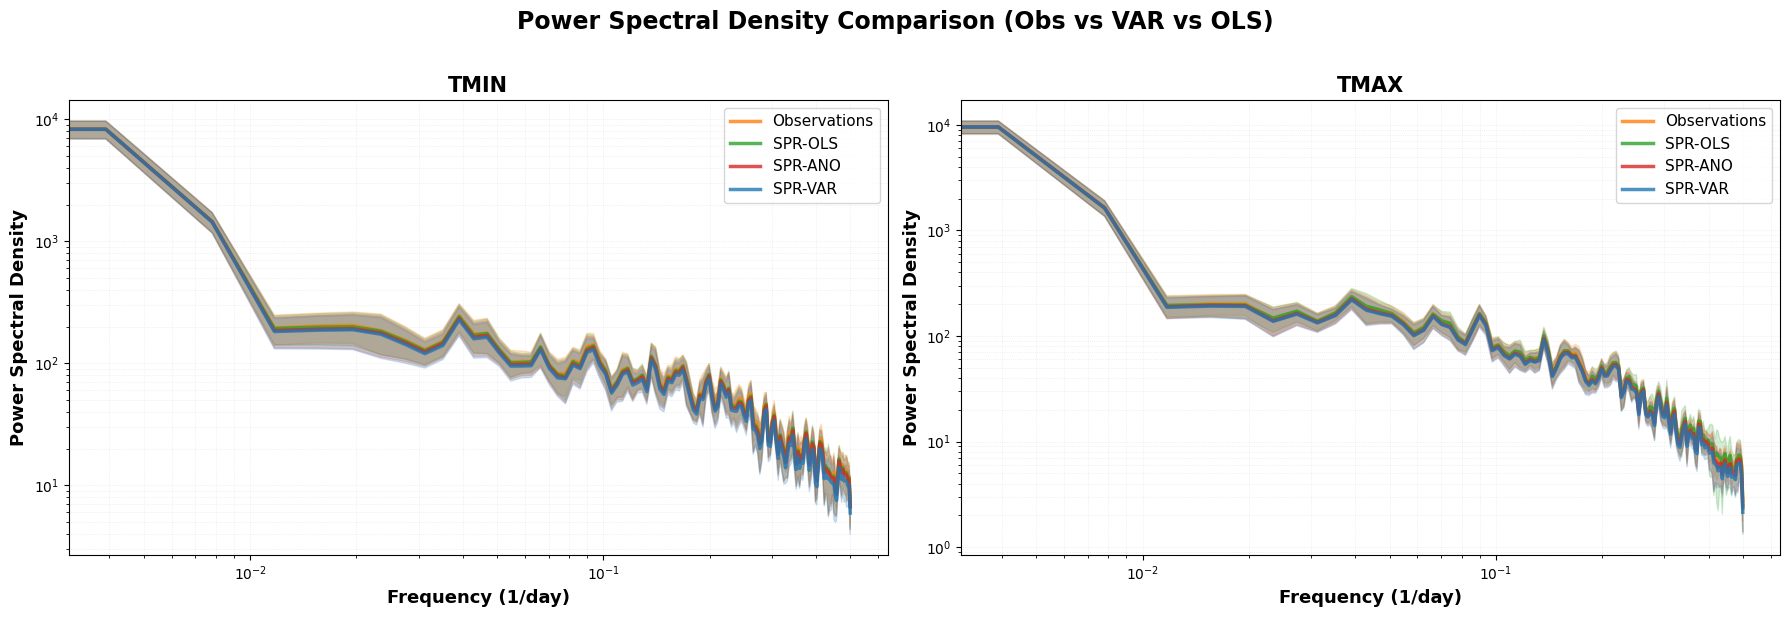

In [33]:
def plot_combined_psd_comparison(
    obs_tmin,
    mod_ols_tmin,
    mod_ano_tmin,
    mod_ano_var_tmin,
    obs_tmax,
    mod_ols_tmax,
    mod_ano_tmax,
    mod_ano_var_tmax,
    psd_nperseg=256,
):
    """
    Plot Power Spectral Density comparison for both TMIN and TMAX in a single figure.
    Shows Observations vs VAR vs OLS.
    """
    import scipy.signal as sps

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    series = [
        (obs_tmin, mod_ols_tmin, mod_ano_tmin, mod_ano_var_tmin, "TMIN", axes[0]),
        (obs_tmax, mod_ols_tmax, mod_ano_tmax, mod_ano_var_tmax, "TMAX", axes[1]),
    ]

    colors = {"OBS": "#ff7f0e", "VAR": "#1f77b4", "ANO": "#d62728", "OLS": "#2ca02c"}

    for obs, mod_ols, mod_ano, mod_ano_var, var_name, ax in series:
        M_ols = mod_ols.to_numpy() if hasattr(mod_ols, "to_numpy") else np.asarray(mod_ols)
        M_ano = mod_ano.to_numpy() if hasattr(mod_ano, "to_numpy") else np.asarray(mod_ano)
        M_ano_var = mod_ano_var.to_numpy() if hasattr(mod_ano_var, "to_numpy") else np.asarray(mod_ano_var)

        O = obs.to_numpy() if hasattr(obs, "to_numpy") else np.asarray(obs)
        T, D = M_ano_var.shape

        def compute_mean_psd(arr):
            psd_list, freqs_list = [], []
            for j in range(D):
                x = _fill_for_psd(arr[:, j])
                x = x - np.mean(x)
                f, Pxx = sps.welch(x, nperseg=min(psd_nperseg, max(8, T // 2)))
                psd_list.append(Pxx)
                freqs_list.append(f)
            L = min(min(len(p) for p in psd_list), min(len(f) for f in freqs_list))
            psd_arr = np.vstack([p[:L] for p in psd_list])
            freqs = np.vstack([f[:L] for f in freqs_list])
            return np.nanmean(freqs, axis=0), np.nanmean(psd_arr, axis=0), np.nanstd(psd_arr, axis=0)

        f_obs, mean_obs, std_obs = compute_mean_psd(O)
        f_ano_var, mean_ano_var, std_ano_var = compute_mean_psd(M_ano_var)
        f_ano, mean_ano, std_ano = compute_mean_psd(M_ano)
        f_ols, mean_ols, std_ols = compute_mean_psd(M_ols)

        ax.loglog(f_obs, mean_obs, "-", label="Observations", linewidth=2.5, color=colors["OBS"], alpha=0.8)
        ax.fill_between(f_obs, mean_obs - std_obs, mean_obs + std_obs, alpha=0.2, color=colors["OBS"])

        ax.loglog(f_ols, mean_ols, "-", label="SPR-OLS", linewidth=2.5, color=colors["OLS"], alpha=0.8)
        ax.fill_between(f_ols, mean_ols - std_ols, mean_ols + std_ols, alpha=0.2, color=colors["OLS"])

        ax.loglog(f_ano, mean_ano, "-", label="SPR-ANO", linewidth=2.5, color=colors["ANO"], alpha=0.8)
        ax.fill_between(f_ano, mean_ano - std_ano, mean_ano + std_ano, alpha=0.2, color=colors["ANO"])
        
        ax.loglog(f_ano_var, mean_ano_var, "-", label="SPR-VAR", linewidth=2.5, color=colors["VAR"], alpha=0.8)
        ax.fill_between(f_ano_var, mean_ano_var - std_ano_var, mean_ano_var + std_ano_var, alpha=0.2, color=colors["VAR"])


        ax.set_xlabel("Frequency (1/day)", fontsize=13, fontweight="bold")
        ax.set_ylabel("Power Spectral Density", fontsize=13, fontweight="bold")
        ax.set_title(f"{var_name}", fontsize=15, fontweight="bold")
        ax.legend(fontsize=11, loc="upper right")
        ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.5, which="both")

    fig.suptitle("Power Spectral Density Comparison (Obs vs VAR vs OLS)", fontsize=17, fontweight="bold", y=1.02)
    plt.tight_layout()
    return fig

print("=" * 60)
print("Generating Combined PSD Comparison Plot")
print("=" * 60)
fig_combined_psd = plot_combined_psd_comparison(
    obs_tmin=data_tasmin_obs_orig_np[:, test_indexes],
    mod_ols_tmin=spr_ols_tmin_A1_1[:, test_indexes],
    mod_ano_tmin=spr_ano_tmin_A1_1[:, test_indexes],
    mod_ano_var_tmin=spr_ano_var_tmin_A1_1[:, test_indexes],
    obs_tmax=data_tasmax_obs_orig_np[:, test_indexes],
    mod_ols_tmax=spr_ols_tmax_A1_1[:, test_indexes],
    mod_ano_tmax=spr_ano_tmax_A1_1[:, test_indexes],
    mod_ano_var_tmax=spr_ano_var_tmax_A1_1[:, test_indexes],
)
plt.show()


### Combined ACF Comparison (TMIN and TMAX)

Generating Combined ACF Comparison Plot


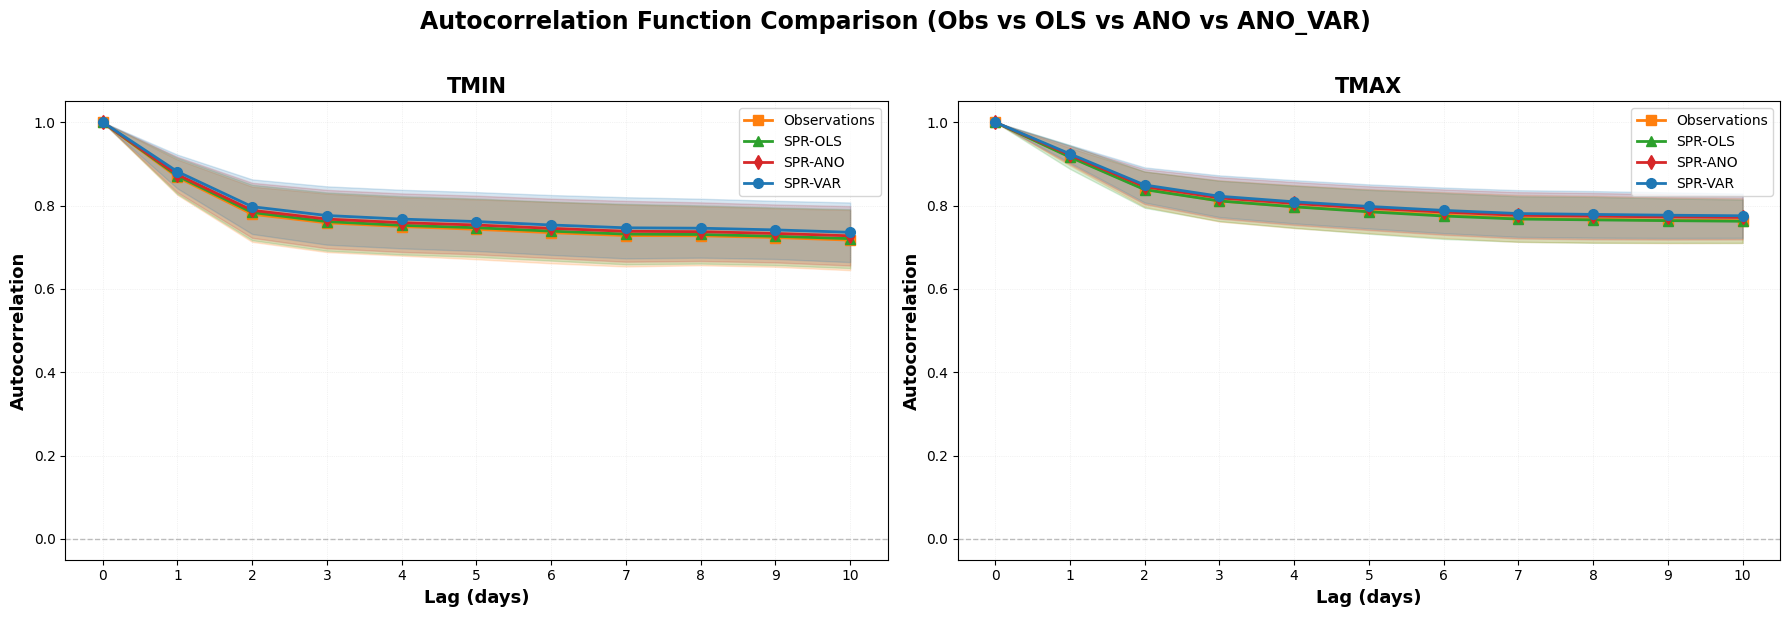

In [34]:
def plot_combined_acf_comparison(
    metrics_tmin,
    metrics_tmax,
):
    """
    Plot ACF comparison for TMIN and TMAX with Observations vs ANO vs VAR vs OLS.
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    series = [
        (metrics_tmin, "TMIN", axes[0]),
        (metrics_tmax, "TMAX", axes[1]),
    ]

    colors = {"OBS": "#ff7f0e", "ANO": "#d62728", "VAR": "#1f77b4", "OLS": "#2ca02c"}

    for metrics, var_name, ax in series:
        # Correct keys from compute_temporal_metrics output
        acf_obs = metrics["acf_lags_matrix_obs"]
        acf_mod_ols = metrics["acf_lags_matrix_mod_ols"]
        acf_mod_ano = metrics["acf_lags_matrix_mod_ano"]
        acf_mod_ano_var = metrics["acf_lags_matrix_mod_ano_var"]

        mean_acf_obs = np.nanmean(acf_obs, axis=0)
        std_acf_obs = np.nanstd(acf_obs, axis=0)

        mean_acf_ano = np.nanmean(acf_mod_ano, axis=0)
        std_acf_ano = np.nanstd(acf_mod_ano, axis=0)

        mean_acf_ano_var = np.nanmean(acf_mod_ano_var, axis=0)
        std_acf_ano_var = np.nanstd(acf_mod_ano_var, axis=0)

        mean_acf_ols = np.nanmean(acf_mod_ols, axis=0)
        std_acf_ols = np.nanstd(acf_mod_ols, axis=0)

        nlags = len(mean_acf_obs) - 1
        lags = np.arange(nlags + 1)

        ax.plot(lags, mean_acf_obs, "s-", label="Observations", linewidth=2, markersize=7, color=colors["OBS"])
        ax.fill_between(lags, mean_acf_obs - 2 * std_acf_obs, mean_acf_obs + 2 * std_acf_obs, alpha=0.18, color=colors["OBS"])

        ax.plot(lags, mean_acf_ols, "^-", label="SPR-OLS", linewidth=2, markersize=7, color=colors["OLS"])
        ax.fill_between(lags, mean_acf_ols - 2 * std_acf_ols, mean_acf_ols + 2 * std_acf_ols, alpha=0.18, color=colors["OLS"])

        ax.plot(lags, mean_acf_ano, "d-", label="SPR-ANO", linewidth=2, markersize=7, color=colors["ANO"])
        ax.fill_between(lags, mean_acf_ano - 2 * std_acf_ano, mean_acf_ano + 2 * std_acf_ano, alpha=0.18, color=colors["ANO"])

        ax.plot(lags, mean_acf_ano_var, "o-", label="SPR-VAR", linewidth=2, markersize=7, color=colors["VAR"])
        ax.fill_between(lags, mean_acf_ano_var - 2 * std_acf_ano_var, mean_acf_ano_var + 2 * std_acf_ano_var, alpha=0.18, color=colors["VAR"])

        ax.axhline(y=0, color="gray", linestyle="--", linewidth=1, alpha=0.5)
        ax.set_xlabel("Lag (days)", fontsize=13, fontweight="bold")
        ax.set_ylabel("Autocorrelation", fontsize=13, fontweight="bold")
        ax.set_title(var_name, fontsize=15, fontweight="bold")
        ax.legend(fontsize=10, loc="upper right")
        ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.5)
        ax.set_xlim(-0.5, nlags + 0.5)
        ax.set_xticks(lags)

    fig.suptitle("Autocorrelation Function Comparison (Obs vs OLS vs ANO vs ANO_VAR)", fontsize=17, fontweight="bold", y=1.02)
    plt.tight_layout()
    return fig


print("=" * 60)
print("Generating Combined ACF Comparison Plot")
print("=" * 60)
fig_combined_acf = plot_combined_acf_comparison(
    temps_spr_tmin,
    temps_spr_tmax,
)
plt.show()


# RMSE Maps

In [35]:
# Make a map plot of station RMSE for TMAX and TMIN
# Replace train values at their places so that RMSE is 0 at train stations
# Function to compute station RMSE
# Average RMSE over all locations
def stations_rmse(mod, obs): # Daily RMSE
    diff = mod - obs
    station_rmse = np.sqrt(np.nanmean(diff**2, axis=0)) # Change axis to 0 to compute per day
    return station_rmse
# Compute station RMSE on the full map data
# TMIN
rmse_tmin_ols_map = stations_rmse(spr_ols_tmin_A1_1, data_tasmin_obs_orig_np)
rmse_tmin_ols_map[train_indexes] = 0.0  # Set RMSE to 0 at training stations
rmse_tmin_ano_map = stations_rmse(spr_ano_tmin_A1_1, data_tasmin_obs_orig_np)
rmse_tmin_ano_map[train_indexes] = 0.0  # Set RMSE to 0 at training stations
rmse_tmin_ano_var_map = stations_rmse(spr_ano_var_tmin_A1_1, data_tasmin_obs_orig_np)
rmse_tmin_ano_var_map[train_indexes] = 0.0  # Set RMSE to 0 at training stations
# TMAX
rmse_tmax_ols_map = stations_rmse(spr_ols_tmax_A1_1, data_tasmax_obs_orig_np)
rmse_tmax_ols_map[train_indexes] = 0.0  # Set RMSE to 0 at training stations
rmse_tmax_ano_map = stations_rmse(spr_ano_tmax_A1_1, data_tasmax_obs_orig_np)
rmse_tmax_ano_map[train_indexes] = 0.0  # Set RMSE to 0 at training stations
rmse_tmax_ano_var_map = stations_rmse(spr_ano_var_tmax_A1_1, data_tasmax_obs_orig_np)
rmse_tmax_ano_var_map[train_indexes] = 0.0  # Set RMSE to 0 at training stations

A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries


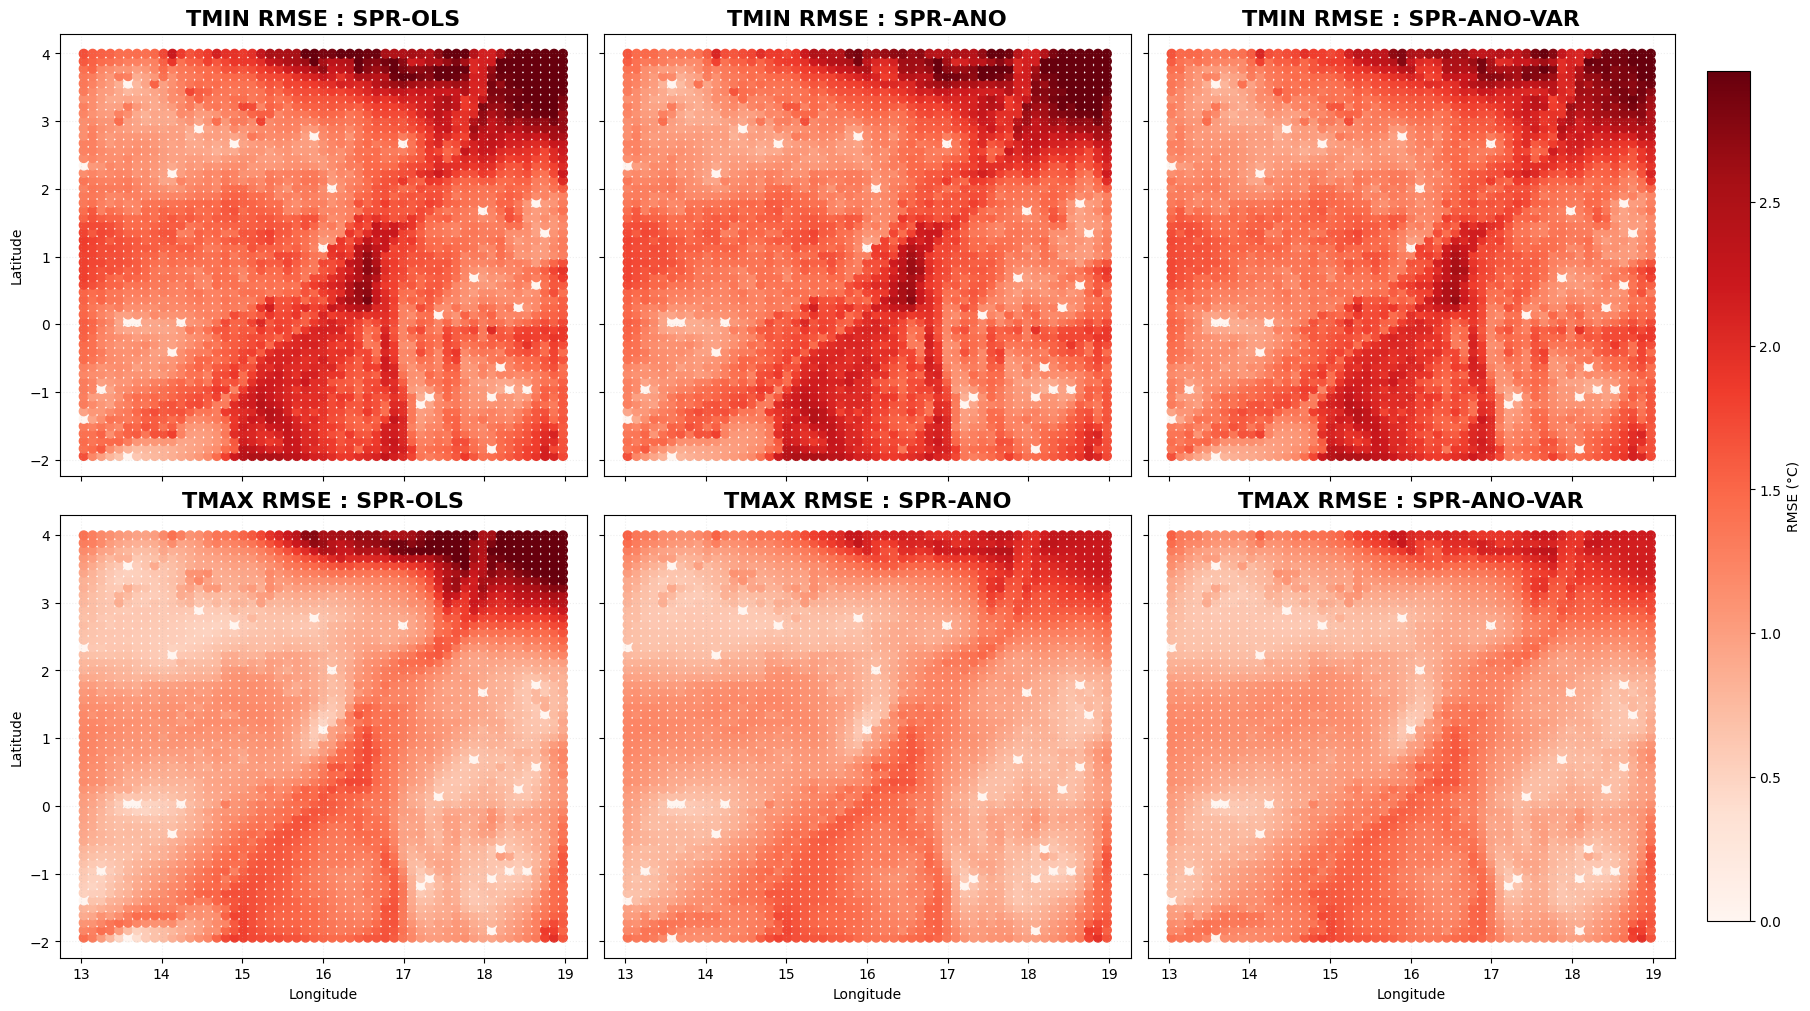

In [36]:
# Plot station RMSE maps in a 2x3 grid (TMIN/TMAX x VAR/ANO/OLS)
def plot_station_rmse_maps(
    lons,
    lats,
    rmse_tmin_ols,
    rmse_tmin_ano,
    rmse_tmin_ano_var,
    rmse_tmax_ols,
    rmse_tmax_ano,
    rmse_tmax_ano_var,
):
    fig, axes = plt.subplots(
        2, 3, figsize=(18, 10), sharex=True, sharey=True, constrained_layout=True
    )

    all_rmse = np.concatenate([
        rmse_tmin_ols, rmse_tmin_ano, rmse_tmin_ano_var,
        rmse_tmax_ols, rmse_tmax_ano, rmse_tmax_ano_var
    ])
    vmin = 0.0
    vmax = np.nanpercentile(all_rmse, 99)

    panels = [
        (0, 0, rmse_tmin_ols, "TMIN RMSE : SPR-OLS"),
        (0, 1, rmse_tmin_ano, "TMIN RMSE : SPR-ANO"),
        (0, 2, rmse_tmin_ano_var, "TMIN RMSE : SPR-ANO-VAR"),
        (1, 0, rmse_tmax_ols, "TMAX RMSE : SPR-OLS"),
        (1, 1, rmse_tmax_ano, "TMAX RMSE : SPR-ANO"),
        (1, 2, rmse_tmax_ano_var, "TMAX RMSE : SPR-ANO-VAR"),
    ]

    mappable = None
    train_handle = None

    for r, c, rmse_vals, title in panels:
        ax = axes[r, c]
        mappable = ax.scatter(
            lons, lats, c=rmse_vals, cmap="Reds", vmin=vmin, vmax=vmax,
            s=40, linewidths=1, rasterized=True  # bigger for smoother-looking color field
        )
        # tr = ax.scatter(
        #     lons[train_indexes], lats[train_indexes],
        #     color="black", marker="x", s=10, linewidths=0.6  # smaller x markers
        # )
        # if train_handle is None:
        #     train_handle = tr

        ax.set_title(title, fontsize=16, fontweight="bold")
        ax.grid(alpha=0.2, linestyle=":")
        if c == 0:
            ax.set_ylabel("Latitude")
        if r == 1:
            ax.set_xlabel("Longitude")

    cbar = fig.colorbar(mappable, ax=axes, location="right", shrink=0.92, pad=0.02)
    cbar.set_label("RMSE (°C)")

    fig.legend([train_handle], ["Train stations"], loc="upper center", ncol=1, frameon=False)

    # fig.suptitle(
    #     "Station RMSE Maps for  SPR-OLS / SPR-ANO / SPR-ANO-VAR",
    #     fontsize=15, fontweight="bold"
    # )
    return fig

# Coordinates for all stations
lons_raw = data_coord_grid.iloc[:, 0]
lats_raw = data_coord_grid.iloc[:, 1]

fig_rmse_maps = plot_station_rmse_maps(
    lons=lons_raw,
    lats=lats_raw,
    rmse_tmin_ols=rmse_tmin_ols_map,
    rmse_tmin_ano=rmse_tmin_ano_map,
    rmse_tmin_ano_var=rmse_tmin_ano_var_map,
    rmse_tmax_ols=rmse_tmax_ols_map,
    rmse_tmax_ano=rmse_tmax_ano_map,
    rmse_tmax_ano_var=rmse_tmax_ano_var_map,
)
plt.show()


# ANALYSES SUR DES ANOMALIES POUR SPR_ANO ET SPR_ANO_VAR

In [37]:
# Performance metrics (observations vs interpolated anomalies) for VAR and OLS
# TMIN
stats_spr_ano_var_tmin = stats_performance(
    mod=anomaly_ano_var_tmin_A1_1[:, test_indexes],
    obs=anomaly_tasmin_obs_orig_np[:, test_indexes]
)

stats_spr_ano_tmin = stats_performance(
    mod=anomaly_ano_tmin_A1_1[:, test_indexes],
    obs=anomaly_tasmin_obs_orig_np[:, test_indexes]
)

stats_spr_ols_tmin = stats_performance(
    mod=anomaly_ols_tmin_A1_1[:, test_indexes],
    obs=anomaly_tasmin_obs_orig_np[:, test_indexes]
)

# TMAX
stats_spr_ano_var_tmax = stats_performance(
    mod=anomaly_ano_var_tmax_A1_1[:, test_indexes],
    obs=anomaly_tasmax_obs_orig_np[:, test_indexes]
)

stats_spr_ano_tmax = stats_performance(
    mod=anomaly_ano_tmax_A1_1[:, test_indexes],
    obs=anomaly_tasmax_obs_orig_np[:, test_indexes]
)

stats_spr_ols_tmax = stats_performance(
    mod=anomaly_ols_tmax_A1_1[:, test_indexes],
    obs=anomaly_tasmax_obs_orig_np[:, test_indexes]
)


def build_perf_table(var_name):
    rows = []
    model_tables = {
        "OLS": stats_spr_ols_tmin if var_name == "TMIN" else stats_spr_ols_tmax,
        "ANO": stats_spr_ano_tmin if var_name == "TMIN" else stats_spr_ano_tmax,
        "VAR": stats_spr_ano_var_tmin if var_name == "TMIN" else stats_spr_ano_var_tmax,
    }
    for model_label, df_stats in model_tables.items():
        tmp = df_stats.copy()
        tmp.insert(0, "Model", f"SPR-{model_label}")
        rows.append(tmp)
    merged = pd.concat(rows, axis=0, ignore_index=True)
    merged.insert(0, "Variable", var_name)
    print("\n" + "#" * 52)
    print(f"Performance against observations: {var_name}")
    print("#" * 52)
    print(merged.to_string(index=False))
    return merged

# Build combined summary table (VAR first, then OLS for each variable)
perf_summary = pd.concat(
    [build_perf_table("TMIN"), build_perf_table("TMAX")],
    axis=0,
    ignore_index=True,
)



####################################################
Performance against observations: TMIN
####################################################
Variable   Model   RMSE_s   RMSE_t      NSE      KGE     SSIM
    TMIN SPR-OLS 1.537182 1.588360 0.911517 0.913769 0.954868
    TMIN SPR-ANO 1.521462 1.569190 0.913630 0.887330 0.952136
    TMIN SPR-VAR 1.499304 1.549287 0.916730 0.887452 0.952151

####################################################
Performance against observations: TMAX
####################################################
Variable   Model   RMSE_s   RMSE_t      NSE      KGE     SSIM
    TMAX SPR-OLS 1.167246 1.164858 0.940209 0.931021 0.970245
    TMAX SPR-ANO 1.098212 1.119641 0.948559 0.892604 0.969811
    TMAX SPR-VAR 1.090353 1.112220 0.949504 0.893242 0.969821


## Temporal structure

In [38]:
# ===== TMIN =====
print("\n" + "=" * 42)
print("TEMPORAL STRUCTURE METRICS: TMIN")
print("=" * 42)

temps_spr_tmin = compute_temporal_metrics(
    anomaly_ols_tmin_A1_1[:, test_indexes],
    anomaly_ano_tmin_A1_1[:, test_indexes],
    anomaly_ano_var_tmin_A1_1[:, test_indexes],
    anomaly_tasmin_obs_orig_np[:, test_indexes],
    nlags=10,
)


# ===== TMAX =====
print("\n" + "=" * 42)
print("TEMPORAL STRUCTURE METRICS: TMAX")
print("=" * 42)

temps_spr_tmax = compute_temporal_metrics(
    anomaly_ols_tmax_A1_1[:, test_indexes],
    anomaly_ano_tmax_A1_1[:, test_indexes],
    anomaly_ano_var_tmax_A1_1[:, test_indexes],
    anomaly_tasmax_obs_orig_np[:, test_indexes],
    nlags=10,
)



TEMPORAL STRUCTURE METRICS: TMIN

TEMPORAL STRUCTURE METRICS: TMAX


In [39]:
def print_temporal_metrics_comparison(metrics, variable_name):
    print(f"\n{'='*50}")
    print(f"TEMPORAL STRUCTURE METRICS: {variable_name}")
    print(f"{'='*50}")

    lag1_obs = metrics["mean_abs_lag1_acf_obs"]
    lag1_ols = metrics["mean_abs_lag1_acf_mod_ols"]
    lag1_ano = metrics["mean_abs_lag1_acf_mod_ano"]
    lag1_ano_var = metrics["mean_abs_lag1_acf_mod_ano_var"]

    decay_obs = metrics["acf_decay_mean_obs"]
    decay_ols = metrics["acf_decay_mean_mod_ols"]
    decay_ano = metrics["acf_decay_mean_mod_ano"]
    decay_ano_var = metrics["acf_decay_mean_mod_ano_var"]

    psd_sim = metrics["psd_cosine_similarity"]

    comparison_data = {
        "Metric": ["Mean |ACF(lag-1)|", "Mean ACF Decay", "PSD Cosine Similarity"],
        "SPR_OLS": [f"{lag1_ols:.4f}", f"{decay_ols:.4f}", f"{psd_sim:.4f}"],
        "SPR_ANO": [f"{lag1_ano:.4f}", f"{decay_ano:.4f}", f"{psd_sim:.4f}"],
        "SPR_ANO_VAR": [f"{lag1_ano_var:.4f}", f"{decay_ano_var:.4f}", f"{psd_sim:.4f}"],
        "Observations": [f"{lag1_obs:.4f}", f"{decay_obs:.4f}", "—"],
    }

    df_comparison = pd.DataFrame(comparison_data)
    print(df_comparison.to_string(index=False))
    print(f"{'='*50}\n")
    return df_comparison


print("\n" + "="*50)
print("TEMPORAL STRUCTURE ANALYSIS: VAR vs ANO vs OLS")
print("="*50)

print_temporal_metrics_comparison(temps_spr_tmin, "TMIN")
print_temporal_metrics_comparison(temps_spr_tmax, "TMAX")



TEMPORAL STRUCTURE ANALYSIS: VAR vs ANO vs OLS

TEMPORAL STRUCTURE METRICS: TMIN
               Metric SPR_OLS SPR_ANO SPR_ANO_VAR Observations
    Mean |ACF(lag-1)|  0.5414  0.5389      0.5514       0.5361
       Mean ACF Decay  0.1208  0.1189      0.1220       0.1199
PSD Cosine Similarity  0.9999  0.9999      0.9999            —


TEMPORAL STRUCTURE METRICS: TMAX
               Metric SPR_OLS SPR_ANO SPR_ANO_VAR Observations
    Mean |ACF(lag-1)|  0.6384  0.6441      0.6513       0.6403
       Mean ACF Decay  0.1388  0.1396      0.1413       0.1391
PSD Cosine Similarity  0.9998  0.9998      0.9998            —



,Metric,SPR_OLS,SPR_ANO,SPR_ANO_VAR,Observations
0,Mean |ACF(lag-1)|,0.6384,0.6441,0.6513,0.6403
1,Mean ACF Decay,0.1388,0.1396,0.1413,0.1391
2,PSD Cosine Similarity,0.9998,0.9998,0.9998,—


## Graphical comparison of temporal structure

### Combined PSD Comparison (TMIN and TMAX)

Generating Combined PSD Comparison Plot


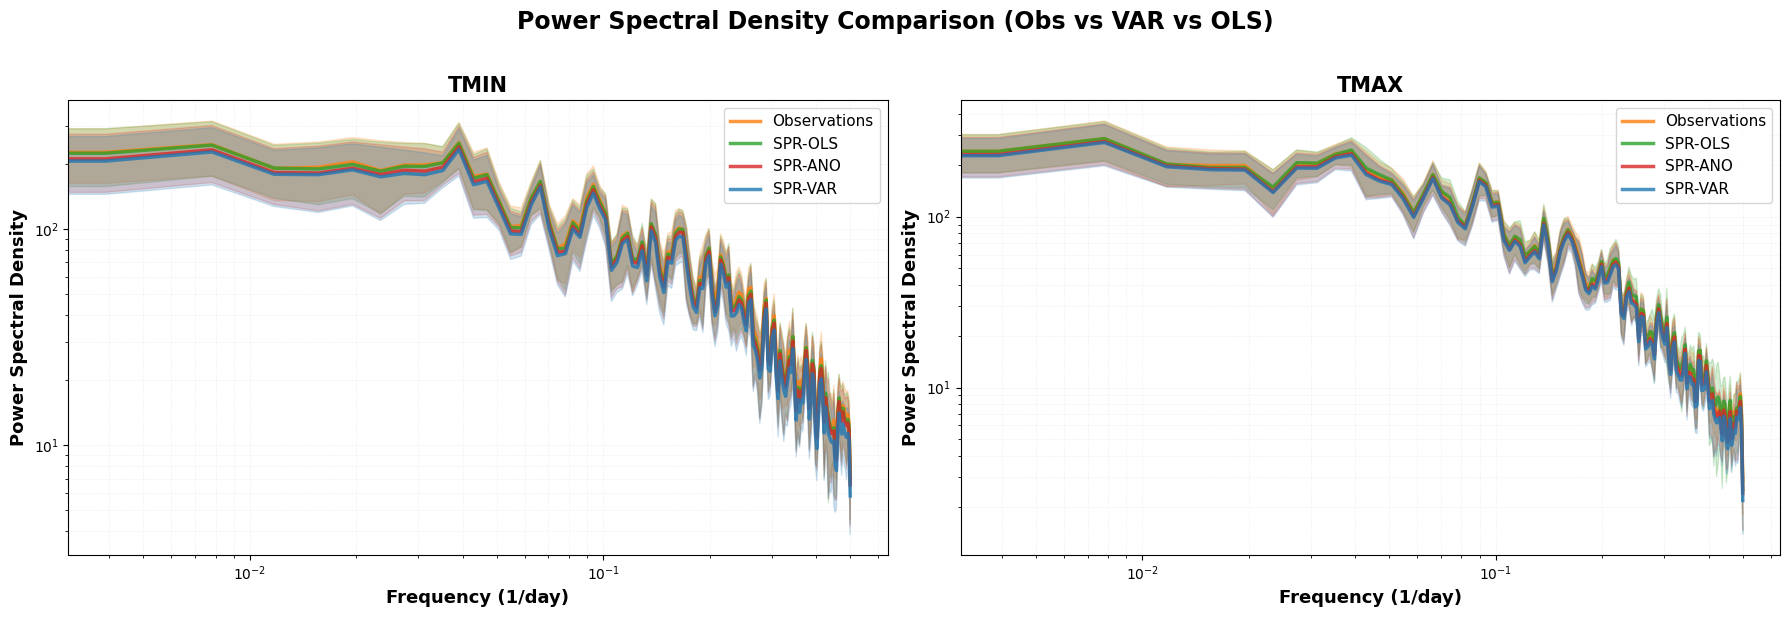

In [40]:
def plot_combined_psd_comparison(
    obs_tmin,
    mod_ols_tmin,
    mod_ano_tmin,
    mod_ano_var_tmin,
    obs_tmax,
    mod_ols_tmax,
    mod_ano_tmax,
    mod_ano_var_tmax,
    psd_nperseg=256,
):
    """
    Plot Power Spectral Density comparison for both TMIN and TMAX in a single figure.
    Shows Observations vs VAR vs OLS.
    """
    import scipy.signal as sps

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    series = [
        (obs_tmin, mod_ols_tmin, mod_ano_tmin, mod_ano_var_tmin, "TMIN", axes[0]),
        (obs_tmax, mod_ols_tmax, mod_ano_tmax, mod_ano_var_tmax, "TMAX", axes[1]),
    ]

    colors = {"OBS": "#ff7f0e", "VAR": "#1f77b4", "ANO": "#d62728", "OLS": "#2ca02c"}

    for obs, mod_ols, mod_ano, mod_ano_var, var_name, ax in series:
        M_ols = mod_ols.to_numpy() if hasattr(mod_ols, "to_numpy") else np.asarray(mod_ols)
        M_ano = mod_ano.to_numpy() if hasattr(mod_ano, "to_numpy") else np.asarray(mod_ano)
        M_ano_var = mod_ano_var.to_numpy() if hasattr(mod_ano_var, "to_numpy") else np.asarray(mod_ano_var)

        O = obs.to_numpy() if hasattr(obs, "to_numpy") else np.asarray(obs)
        T, D = M_ano_var.shape

        def compute_mean_psd(arr):
            psd_list, freqs_list = [], []
            for j in range(D):
                x = _fill_for_psd(arr[:, j])
                x = x - np.mean(x)
                f, Pxx = sps.welch(x, nperseg=min(psd_nperseg, max(8, T // 2)))
                psd_list.append(Pxx)
                freqs_list.append(f)
            L = min(min(len(p) for p in psd_list), min(len(f) for f in freqs_list))
            psd_arr = np.vstack([p[:L] for p in psd_list])
            freqs = np.vstack([f[:L] for f in freqs_list])
            return np.nanmean(freqs, axis=0), np.nanmean(psd_arr, axis=0), np.nanstd(psd_arr, axis=0)

        f_obs, mean_obs, std_obs = compute_mean_psd(O)
        f_ano_var, mean_ano_var, std_ano_var = compute_mean_psd(M_ano_var)
        f_ano, mean_ano, std_ano = compute_mean_psd(M_ano)
        f_ols, mean_ols, std_ols = compute_mean_psd(M_ols)

        ax.loglog(f_obs, mean_obs, "-", label="Observations", linewidth=2.5, color=colors["OBS"], alpha=0.8)
        ax.fill_between(f_obs, mean_obs - std_obs, mean_obs + std_obs, alpha=0.2, color=colors["OBS"])

        ax.loglog(f_ols, mean_ols, "-", label="SPR-OLS", linewidth=2.5, color=colors["OLS"], alpha=0.8)
        ax.fill_between(f_ols, mean_ols - std_ols, mean_ols + std_ols, alpha=0.2, color=colors["OLS"])

        ax.loglog(f_ano, mean_ano, "-", label="SPR-ANO", linewidth=2.5, color=colors["ANO"], alpha=0.8)
        ax.fill_between(f_ano, mean_ano - std_ano, mean_ano + std_ano, alpha=0.2, color=colors["ANO"])
        
        ax.loglog(f_ano_var, mean_ano_var, "-", label="SPR-VAR", linewidth=2.5, color=colors["VAR"], alpha=0.8)
        ax.fill_between(f_ano_var, mean_ano_var - std_ano_var, mean_ano_var + std_ano_var, alpha=0.2, color=colors["VAR"])


        ax.set_xlabel("Frequency (1/day)", fontsize=13, fontweight="bold")
        ax.set_ylabel("Power Spectral Density", fontsize=13, fontweight="bold")
        ax.set_title(f"{var_name}", fontsize=15, fontweight="bold")
        ax.legend(fontsize=11, loc="upper right")
        ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.5, which="both")

    fig.suptitle("Power Spectral Density Comparison (Obs vs VAR vs OLS)", fontsize=17, fontweight="bold", y=1.02)
    plt.tight_layout()
    return fig

print("=" * 60)
print("Generating Combined PSD Comparison Plot")
print("=" * 60)
fig_combined_psd = plot_combined_psd_comparison(
    obs_tmin=anomaly_tasmin_obs_orig_np[:, test_indexes],
    mod_ols_tmin=anomaly_ols_tmin_A1_1[:, test_indexes],
    mod_ano_tmin=anomaly_ano_tmin_A1_1[:, test_indexes],
    mod_ano_var_tmin=anomaly_ano_var_tmin_A1_1[:, test_indexes],
    obs_tmax=anomaly_tasmax_obs_orig_np[:, test_indexes],
    mod_ols_tmax=anomaly_ols_tmax_A1_1[:, test_indexes],
    mod_ano_tmax=anomaly_ano_tmax_A1_1[:, test_indexes],
    mod_ano_var_tmax=anomaly_ano_var_tmax_A1_1[:, test_indexes],
)
plt.show()


### Combined ACF Comparison (TMIN and TMAX)

Generating Combined ACF Comparison Plot


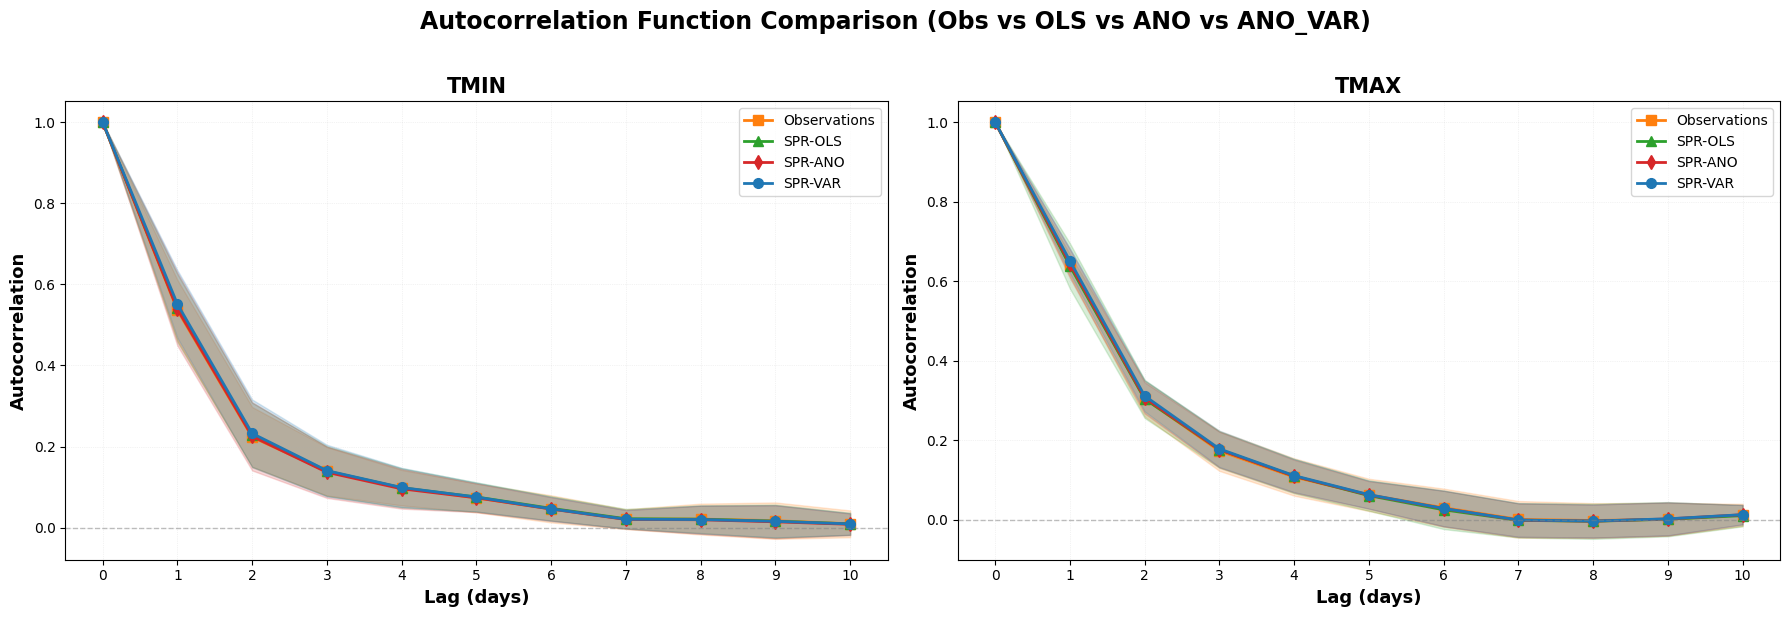

In [41]:
def plot_combined_acf_comparison(
    metrics_tmin,
    metrics_tmax,
):
    """
    Plot ACF comparison for TMIN and TMAX with Observations vs ANO vs VAR vs OLS.
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    series = [
        (metrics_tmin, "TMIN", axes[0]),
        (metrics_tmax, "TMAX", axes[1]),
    ]

    colors = {"OBS": "#ff7f0e", "ANO": "#d62728", "VAR": "#1f77b4", "OLS": "#2ca02c"}

    for metrics, var_name, ax in series:
        # Correct keys from compute_temporal_metrics output
        acf_obs = metrics["acf_lags_matrix_obs"]
        acf_mod_ols = metrics["acf_lags_matrix_mod_ols"]
        acf_mod_ano = metrics["acf_lags_matrix_mod_ano"]
        acf_mod_ano_var = metrics["acf_lags_matrix_mod_ano_var"]

        mean_acf_obs = np.nanmean(acf_obs, axis=0)
        std_acf_obs = np.nanstd(acf_obs, axis=0)

        mean_acf_ano = np.nanmean(acf_mod_ano, axis=0)
        std_acf_ano = np.nanstd(acf_mod_ano, axis=0)

        mean_acf_ano_var = np.nanmean(acf_mod_ano_var, axis=0)
        std_acf_ano_var = np.nanstd(acf_mod_ano_var, axis=0)

        mean_acf_ols = np.nanmean(acf_mod_ols, axis=0)
        std_acf_ols = np.nanstd(acf_mod_ols, axis=0)

        nlags = len(mean_acf_obs) - 1
        lags = np.arange(nlags + 1)

        ax.plot(lags, mean_acf_obs, "s-", label="Observations", linewidth=2, markersize=7, color=colors["OBS"])
        ax.fill_between(lags, mean_acf_obs - 2 * std_acf_obs, mean_acf_obs + 2 * std_acf_obs, alpha=0.18, color=colors["OBS"])

        ax.plot(lags, mean_acf_ols, "^-", label="SPR-OLS", linewidth=2, markersize=7, color=colors["OLS"])
        ax.fill_between(lags, mean_acf_ols - 2 * std_acf_ols, mean_acf_ols + 2 * std_acf_ols, alpha=0.18, color=colors["OLS"])

        ax.plot(lags, mean_acf_ano, "d-", label="SPR-ANO", linewidth=2, markersize=7, color=colors["ANO"])
        ax.fill_between(lags, mean_acf_ano - 2 * std_acf_ano, mean_acf_ano + 2 * std_acf_ano, alpha=0.18, color=colors["ANO"])

        ax.plot(lags, mean_acf_ano_var, "o-", label="SPR-VAR", linewidth=2, markersize=7, color=colors["VAR"])
        ax.fill_between(lags, mean_acf_ano_var - 2 * std_acf_ano_var, mean_acf_ano_var + 2 * std_acf_ano_var, alpha=0.18, color=colors["VAR"])

        ax.axhline(y=0, color="gray", linestyle="--", linewidth=1, alpha=0.5)
        ax.set_xlabel("Lag (days)", fontsize=13, fontweight="bold")
        ax.set_ylabel("Autocorrelation", fontsize=13, fontweight="bold")
        ax.set_title(var_name, fontsize=15, fontweight="bold")
        ax.legend(fontsize=10, loc="upper right")
        ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.5)
        ax.set_xlim(-0.5, nlags + 0.5)
        ax.set_xticks(lags)

    fig.suptitle("Autocorrelation Function Comparison (Obs vs OLS vs ANO vs ANO_VAR)", fontsize=17, fontweight="bold", y=1.02)
    plt.tight_layout()
    return fig


print("=" * 60)
print("Generating Combined ACF Comparison Plot")
print("=" * 60)
fig_combined_acf = plot_combined_acf_comparison(
    temps_spr_tmin,
    temps_spr_tmax,
)
plt.show()


# RMSE Maps

In [42]:
# Make a map plot of station RMSE for TMAX and TMIN
# Replace train values at their places so that RMSE is 0 at train stations
# Function to compute station RMSE
# Average RMSE over all locations
def stations_rmse(mod, obs): # Daily RMSE
    diff = mod - obs
    station_rmse = np.sqrt(np.nanmean(diff**2, axis=0)) # Change axis to 0 to compute per day
    return station_rmse
# Compute station RMSE on the full map data
# TMIN
rmse_tmin_ols_map = stations_rmse(anomaly_ols_tmin_A1_1, anomaly_tasmin_obs_orig_np)
rmse_tmin_ols_map[train_indexes] = 0.0  # Set RMSE to 0 at training stations
rmse_tmin_ano_map = stations_rmse(anomaly_ano_tmin_A1_1, anomaly_tasmin_obs_orig_np)
rmse_tmin_ano_map[train_indexes] = 0.0  # Set RMSE to 0 at training stations
rmse_tmin_ano_var_map = stations_rmse(anomaly_ano_var_tmin_A1_1, anomaly_tasmin_obs_orig_np)
rmse_tmin_ano_var_map[train_indexes] = 0.0  # Set RMSE to 0 at training stations
# TMAX
rmse_tmax_ols_map = stations_rmse(anomaly_ols_tmax_A1_1, anomaly_tasmax_obs_orig_np)
rmse_tmax_ols_map[train_indexes] = 0.0  # Set RMSE to 0 at training stations
rmse_tmax_ano_map = stations_rmse(anomaly_ano_tmax_A1_1, anomaly_tasmax_obs_orig_np)
rmse_tmax_ano_map[train_indexes] = 0.0  # Set RMSE to 0 at training stations
rmse_tmax_ano_var_map = stations_rmse(anomaly_ano_var_tmax_A1_1, anomaly_tasmax_obs_orig_np)
rmse_tmax_ano_var_map[train_indexes] = 0.0  # Set RMSE to 0 at training stations

A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries


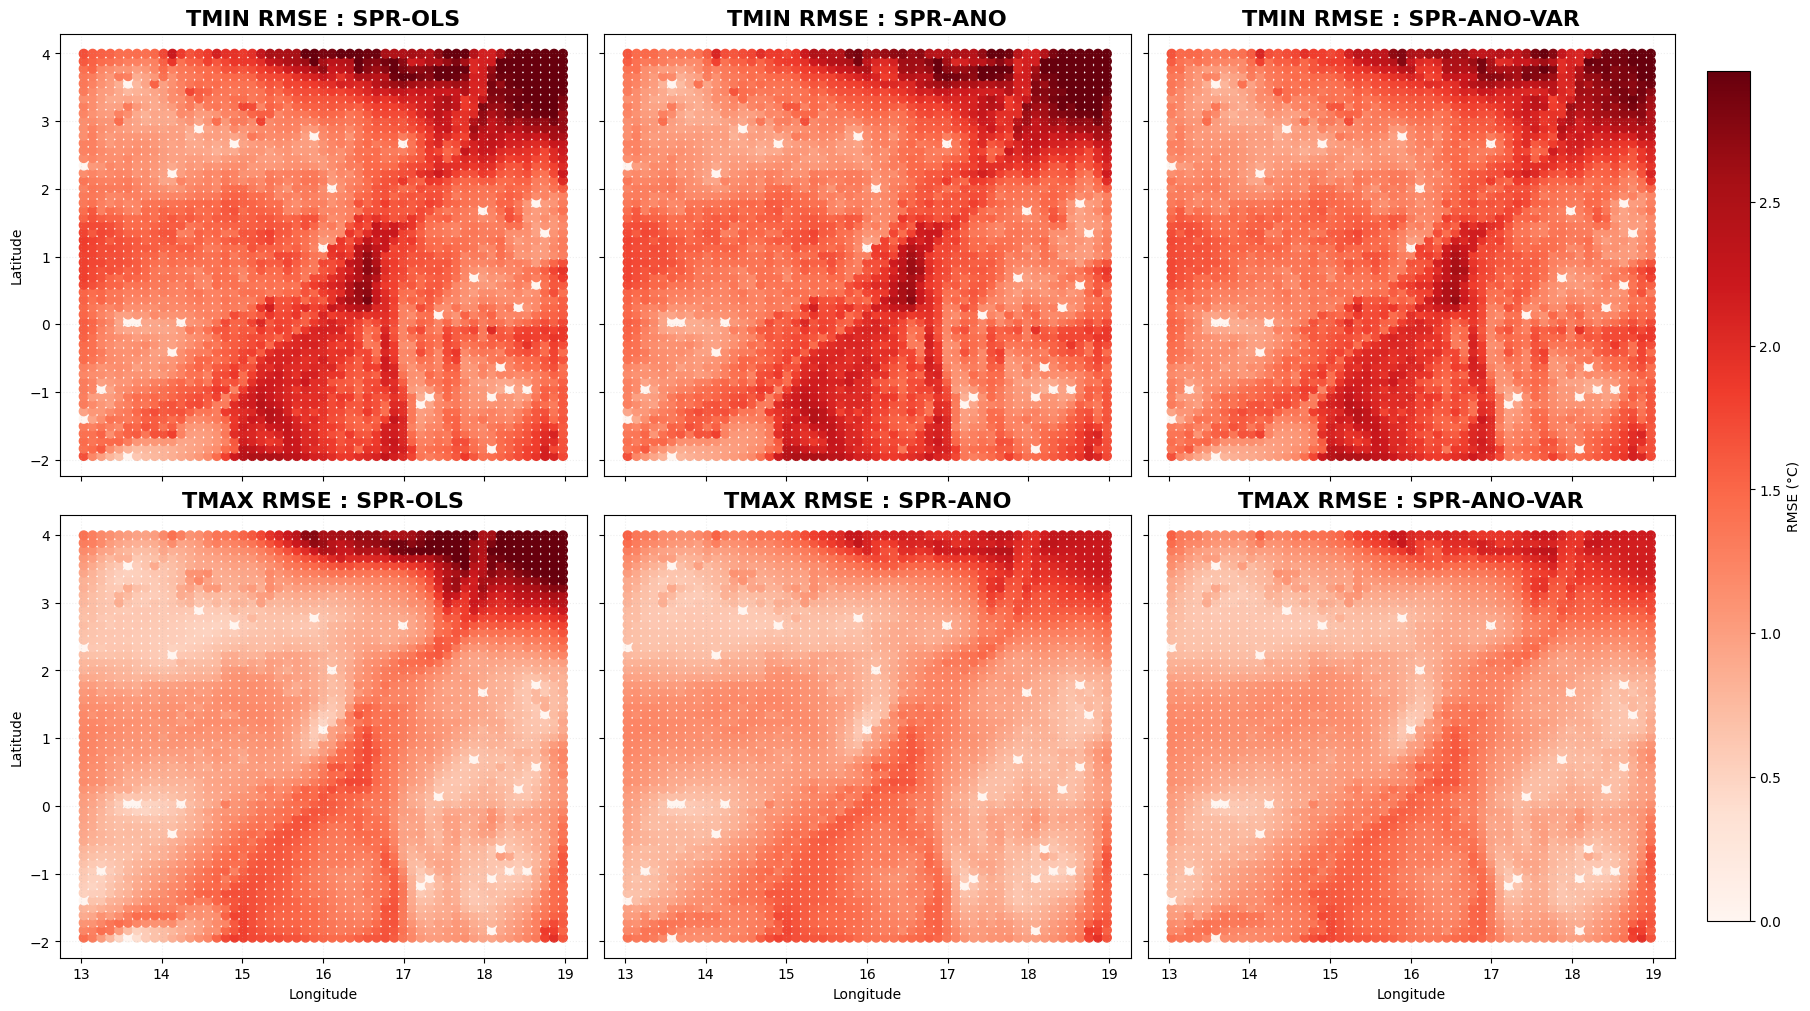

In [43]:
# Plot station RMSE maps in a 2x3 grid (TMIN/TMAX x VAR/ANO/OLS)
def plot_station_rmse_maps(
    lons,
    lats,
    rmse_tmin_ols,
    rmse_tmin_ano,
    rmse_tmin_ano_var,
    rmse_tmax_ols,
    rmse_tmax_ano,
    rmse_tmax_ano_var,
):
    fig, axes = plt.subplots(
        2, 3, figsize=(18, 10), sharex=True, sharey=True, constrained_layout=True
    )

    all_rmse = np.concatenate([
        rmse_tmin_ols, rmse_tmin_ano, rmse_tmin_ano_var,
        rmse_tmax_ols, rmse_tmax_ano, rmse_tmax_ano_var
    ])
    vmin = 0.0
    vmax = np.nanpercentile(all_rmse, 99)

    panels = [
        (0, 0, rmse_tmin_ols, "TMIN RMSE : SPR-OLS"),
        (0, 1, rmse_tmin_ano, "TMIN RMSE : SPR-ANO"),
        (0, 2, rmse_tmin_ano_var, "TMIN RMSE : SPR-ANO-VAR"),
        (1, 0, rmse_tmax_ols, "TMAX RMSE : SPR-OLS"),
        (1, 1, rmse_tmax_ano, "TMAX RMSE : SPR-ANO"),
        (1, 2, rmse_tmax_ano_var, "TMAX RMSE : SPR-ANO-VAR"),
    ]

    mappable = None
    train_handle = None

    for r, c, rmse_vals, title in panels:
        ax = axes[r, c]
        mappable = ax.scatter(
            lons, lats, c=rmse_vals, cmap="Reds", vmin=vmin, vmax=vmax,
            s=40, linewidths=1, rasterized=True  # bigger for smoother-looking color field
        )
        # tr = ax.scatter(
        #     lons[train_indexes], lats[train_indexes],
        #     color="black", marker="x", s=10, linewidths=0.6  # smaller x markers
        # )
        # if train_handle is None:
        #     train_handle = tr

        ax.set_title(title, fontsize=16, fontweight="bold")
        ax.grid(alpha=0.2, linestyle=":")
        if c == 0:
            ax.set_ylabel("Latitude")
        if r == 1:
            ax.set_xlabel("Longitude")

    cbar = fig.colorbar(mappable, ax=axes, location="right", shrink=0.92, pad=0.02)
    cbar.set_label("RMSE (°C)")

    fig.legend([train_handle], ["Train stations"], loc="upper center", ncol=1, frameon=False)

    # fig.suptitle(
    #     "Station RMSE Maps for  SPR-OLS / SPR-ANO / SPR-ANO-VAR",
    #     fontsize=15, fontweight="bold"
    # )
    return fig

# Coordinates for all stations
lons_raw = data_coord_grid.iloc[:, 0]
lats_raw = data_coord_grid.iloc[:, 1]

fig_rmse_maps = plot_station_rmse_maps(
    lons=lons_raw,
    lats=lats_raw,
    rmse_tmin_ols=rmse_tmin_ols_map,
    rmse_tmin_ano=rmse_tmin_ano_map,
    rmse_tmin_ano_var=rmse_tmin_ano_var_map,
    rmse_tmax_ols=rmse_tmax_ols_map,
    rmse_tmax_ano=rmse_tmax_ano_map,
    rmse_tmax_ano_var=rmse_tmax_ano_var_map,
)
plt.show()
